<div style="text-align: center; padding: 30px 24px; border-radius: 18px; background: linear-gradient(135deg, #F4F7FB 0%, #E8F1FB 100%); border: 1px solid #D6E4F0; user-select: text; -webkit-user-select: text; cursor: text;">
  <div style="margin-bottom: 18px;">
    <img src="../assets/images/ualbany_logo.png" alt="University at Albany logo" style="width: 340px; max-width: 100%; height: auto;">
  </div>
  <p style="margin: 0 0 10px 0; font-family: Arial, sans-serif; font-size: 16px; color: #5B2A86; letter-spacing: 0.8px; text-transform: uppercase; user-select: text; -webkit-user-select: text; cursor: text;">
    University at Albany, State University of New York
  </p>
  <h1 style="margin: 0; font-family: Arial, sans-serif; font-size: 34px; color: #12355B; letter-spacing: 0.4px; user-select: text; -webkit-user-select: text; cursor: text;">
    Regression Model of U.S. House Prices
  </h1>
  <p style="margin-top: 12px; margin-bottom: 6px; font-family: Arial, sans-serif; font-size: 18px; color: #8C1C13; user-select: text; -webkit-user-select: text; cursor: text;">
    Hector G. Castillo M.
  </p>
  <p style="margin-top: 0; margin-bottom: 0; font-family: Arial, sans-serif; font-size: 16px; color: #4F5D75; user-select: text; -webkit-user-select: text; cursor: text;">
    Showcase Project in R
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 1. Connect to the Dataset</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    We begin by loading the <b>USA Real Estate Dataset.csv</b> file into R and inspecting its overall size, column names, and first rows. This gives us the raw version of the dataset before any cleaning or modeling decisions are made.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The goal of this project is to build a regression workflow to predict <b>house prices</b> across <b>U.S. states and territories</b>. We will move step by step: inspect the raw data first, curate the dataset, define the target variable, and then compare regression methods in a structured way.
  </p>
</div>


In [470]:
# 1: Load the raw real-estate dataset and inspect its basic structure

options(scipen = 999)

full_dataset_path <- file.path("..", "data", "USA Real Estate Dataset.csv")
sample_dataset_path <- file.path("..", "data", "USA Real Estate Dataset_sample.csv")
dataset_path <- if (file.exists(full_dataset_path)) full_dataset_path else sample_dataset_path

real_estate_data <- read.csv(dataset_path, stringsAsFactors = FALSE)
cat("Using dataset file:", dataset_path, "\n")

dataset_overview <- data.frame(
  Metric = c("Number of rows", "Number of columns"),
  Value = c(nrow(real_estate_data), ncol(real_estate_data)),
  stringsAsFactors = FALSE
)

column_names_table <- data.frame(
  Column = names(real_estate_data),
  stringsAsFactors = FALSE
)

dataset_overview
column_names_table
head(real_estate_data)


Metric,Value
<chr>,<int>
Number of rows,1471301
Number of columns,12


Column
<chr>
brokered_by
price
bed
bath
acre_lot
street
city
state
house_size


,brokered_by,price,bed,bath,acre_lot,street,city,state,house_size,price_per_sqft,price_per_acre,area_type
,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>
1,103378,105000,3,2,0.12,1962661,Adjuntas,Puerto Rico,920,114.13,875000.0,urban
2,52707,80000,4,2,0.08,1902874,Adjuntas,Puerto Rico,1527,52.39,1000000.0,urban
3,103379,67000,2,1,0.15,1404990,Juana Diaz,Puerto Rico,748,89.57,446666.7,urban
4,31239,145000,4,2,0.10,1947675,Ponce,Puerto Rico,1800,80.56,1450000.0,urban
5,103378,179000,4,3,0.46,1850806,San Sebastian,Puerto Rico,2520,71.03,389130.4,suburban
6,1205,50000,3,1,0.20,1298094,Ciales,Puerto Rico,2040,24.51,250000.0,urban


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 2. First Data-Quality Review</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    Before fitting any regression model, we check for missing values, exact duplicates, and variables that may create methodological problems. This step is important because regression results can become misleading if the dataset contains duplicated observations, identifier-like variables, or predictors that are directly derived from the target.
  </p>
  <div style="background: #FFF7ED; border: 1px solid #FDBA74; border-left: 6px solid #F97316; padding: 12px 14px; border-radius: 10px;">
    <p style="margin: 0; font-size: 15px; color: #7C2D12; line-height: 1.7;">
      Initial warning signs in this dataset include <b>exact duplicate rows</b>, missing values in <b>street</b> and <b>brokered_by</b>, very low listing prices that may behave like placeholders or auction values, and target-derived variables such as <b>price_per_sqft</b> and <b>price_per_acre</b>. Those derived variables may cause <b>target leakage</b> if the objective is to predict <b>price</b> itself.
    </p>
  </div>
</div>


In [471]:
# 2: Review duplicates, missing values, and raw data-quality counts

missing_values_table <- data.frame(
  Column = names(real_estate_data),
  Missing_Values = as.integer(colSums(is.na(real_estate_data))),
  stringsAsFactors = FALSE
)

missing_values_table <- missing_values_table[
  order(-missing_values_table$Missing_Values, missing_values_table$Column),
]

data_quality_counts <- data.frame(
  Metric = c(
    "Exact duplicate rows",
    "Missing values in street",
    "Missing values in brokered_by",
    "Very low prices (<= $1,000)",
    "Rows from Puerto Rico",
    "Target-derived variables to exclude"
  ),
  Value = c(
    sum(duplicated(real_estate_data)),
    sum(is.na(real_estate_data$street)),
    sum(is.na(real_estate_data$brokered_by)),
    sum(real_estate_data$price <= 1000, na.rm = TRUE),
    sum(real_estate_data$state == "Puerto Rico", na.rm = TRUE),
    2
  ),
  stringsAsFactors = FALSE
)

missing_values_table
data_quality_counts


,Column,Missing_Values
,<chr>,<int>
6,street,4808
1,brokered_by,2343
5,acre_lot,0
12,area_type,0
4,bath,0
3,bed,0
7,city,0
9,house_size,0
2,price,0


Metric,Value
<chr>,<dbl>
Exact duplicate rows,92413
Missing values in street,4808
Missing values in brokered_by,2343
"Very low prices (<= $1,000)",354
Rows from Puerto Rico,2190
Target-derived variables to exclude,2


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    This first review suggests that <b>street</b> and <b>brokered_by</b> should not be part of the baseline regression model, because they combine missing values with identifier-like behavior. It also shows that the dataset contains a nontrivial number of <b>exact duplicates</b> and a small set of <b>very low prices</b> that are likely inconsistent with a standard residential pricing problem.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    Finally, <b>price_per_sqft</b> and <b>price_per_acre</b> will be excluded because they are derived directly from the target, while <b>Puerto Rico</b> will remain included because the project scope covers <b>U.S. states and territories</b>.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 3. Document the Variables</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    We create a variable table with the column name, data type, role, and a short description. This makes the project easier to explain in the showcase and helps us separate the <b>target</b>, the <b>candidate predictors</b>, and the variables that should be excluded from the main regression model.
  </p>
</div>


In [472]:
# 3: Build a variable dictionary for the regression project

variable_descriptions <- c(
  brokered_by = "Broker identifier",
  price = "Target variable: listing price of the property",
  bed = "Number of bedrooms",
  bath = "Number of bathrooms",
  acre_lot = "Lot size in acres",
  street = "Street identifier / address reference",
  city = "City where the property is located",
  state = "State or territory where the property is located",
  house_size = "Interior house size",
  price_per_sqft = "Derived variable: price divided by house size",
  price_per_acre = "Derived variable: price divided by lot size",
  area_type = "Area classification such as urban or suburban"
)

variable_roles <- c(
  brokered_by = "Candidate predictor (review carefully)",
  price = "Target",
  bed = "Candidate predictor",
  bath = "Candidate predictor",
  acre_lot = "Candidate predictor",
  street = "Exclude from main model",
  city = "Candidate predictor",
  state = "Candidate predictor",
  house_size = "Candidate predictor",
  price_per_sqft = "Exclude from main model",
  price_per_acre = "Exclude from main model",
  area_type = "Candidate predictor"
)

variables_table <- data.frame(
  Column = names(real_estate_data),
  Data_Type = vapply(real_estate_data, function(x) class(x)[1], character(1)),
  Role = unname(variable_roles[names(real_estate_data)]),
  Description = unname(variable_descriptions[names(real_estate_data)]),
  stringsAsFactors = FALSE
)

variables_table


,Column,Data_Type,Role,Description
,<chr>,<chr>,<chr>,<chr>
brokered_by,brokered_by,integer,Candidate predictor (review carefully),Broker identifier
price,price,numeric,Target,Target variable: listing price of the property
bed,bed,integer,Candidate predictor,Number of bedrooms
bath,bath,integer,Candidate predictor,Number of bathrooms
acre_lot,acre_lot,numeric,Candidate predictor,Lot size in acres
street,street,numeric,Exclude from main model,Street identifier / address reference
city,city,character,Candidate predictor,City where the property is located
state,state,character,Candidate predictor,State or territory where the property is located
house_size,house_size,integer,Candidate predictor,Interior house size


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 4. Define the Main Regression Setup</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    Our response variable will be <b>price</b>. For the main regression workflow, we create a curated version of the dataset with exact duplicates removed, with extremely low listing prices filtered out, and with an explicit list of variables that should be excluded from the first clean regression model.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    At this stage, the most important exclusions are <b>price_per_sqft</b> and <b>price_per_acre</b> because they are algebraically derived from the target variable. We also exclude <b>street</b> and <b>brokered_by</b> from the main model because they behave like identifier-heavy fields, have missing values, and reduce interpretability. Puerto Rico remains included because the project scope covers <b>U.S. states and territories</b>.
  </p>
</div>


In [473]:
# 4: Create a curated dataset and define the main modeling variables

curated_real_estate_data <- real_estate_data[
  !duplicated(real_estate_data) & real_estate_data$price >= 5000,
]

target_variable <- "price"

excluded_from_main_model <- c(
  "price_per_sqft",
  "price_per_acre",
  "street",
  "brokered_by"
)

main_regression_predictors <- setdiff(
  names(curated_real_estate_data),
  c(target_variable, excluded_from_main_model)
)


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 5. Feature Engineering</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    Before fitting regression models, we document the main feature-engineering decisions used to define the first modeling dataset. These decisions are meant to improve methodological clarity, reduce noise, and avoid predictors that would make the model look artificially strong without improving real predictive value.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The most important choices are to remove exact duplicates, filter out listings with <b>price &lt; $5,000</b>, exclude <b>street</b> and <b>brokered_by</b> from the main model, and keep <b>Puerto Rico</b> within the scope of <b>U.S. states and territories</b>. Another necessary step is to treat <b>city</b>, <b>state</b>, and <b>area_type</b> as categorical predictors so that R can encode them correctly inside the regression formulas.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    After these decisions, the baseline regression will focus on structural housing variables such as <b>bed</b>, <b>bath</b>, <b>acre_lot</b>, and <b>house_size</b>, together with the location variables <b>city</b>, <b>state</b>, and <b>area_type</b>. This gives us a clean starting design that is interpretable and methodologically consistent.
  </p>
</div>


In [474]:
# 5: Define the predictor groups and preview the curated regression dataset

categorical_predictors <- c("city", "state", "area_type")
numeric_predictors <- setdiff(main_regression_predictors, categorical_predictors)

regression_ready_data <- curated_real_estate_data[, c(target_variable, main_regression_predictors)]

regression_ready_columns <- data.frame(
  Column = names(regression_ready_data),
  Data_Type = vapply(regression_ready_data, function(x) class(x)[1], character(1)),
  stringsAsFactors = FALSE
)

regression_ready_overview <- data.frame(
  Metric = c(
    "Rows after removing exact duplicates and filtering price >= 5000",
    "Columns in regression-ready dataset"
  ),
  Value = c(nrow(regression_ready_data), ncol(regression_ready_data)),
  stringsAsFactors = FALSE
)

regression_ready_overview
regression_ready_columns
head(regression_ready_data)


Metric,Value
<chr>,<int>
Rows after removing exact duplicates and filtering price >= 5000,1378406
Columns in regression-ready dataset,8


,Column,Data_Type
,<chr>,<chr>
price,price,numeric
bed,bed,integer
bath,bath,integer
acre_lot,acre_lot,numeric
city,city,character
state,state,character
house_size,house_size,integer
area_type,area_type,character


,price,bed,bath,acre_lot,city,state,house_size,area_type
,<dbl>,<int>,<int>,<dbl>,<chr>,<chr>,<int>,<chr>
1,105000,3,2,0.12,Adjuntas,Puerto Rico,920,urban
2,80000,4,2,0.08,Adjuntas,Puerto Rico,1527,urban
3,67000,2,1,0.15,Juana Diaz,Puerto Rico,748,urban
4,145000,4,2,0.10,Ponce,Puerto Rico,1800,urban
5,179000,4,3,0.46,San Sebastian,Puerto Rico,2520,suburban
6,50000,3,1,0.20,Ciales,Puerto Rico,2040,urban


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 6. Prepare the Modeling Data and Create the 80/20 Train-Test Split</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    We now create the dataset that will be used in the modeling stage. To make the structure explicit, the quantitative predictors are converted to <b>numeric</b> and the qualitative predictors are converted to <b>factor</b>. This is useful because regression models in R rely on those data types to build the design matrix correctly.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    After defining the variable types, we split the data into <b>80% training</b> and <b>20% testing</b>. The training set will be used to fit the regression models, while the testing set will be reserved for out-of-sample evaluation. We also print the factor levels so that the categorical structure of the dataset is documented before modeling begins.
  </p>
</div>


In [475]:
# 6: Convert data types explicitly and create the 80/20 train-test split

regression_model_data <- regression_ready_data

regression_model_data[[target_variable]] <- as.numeric(regression_model_data[[target_variable]])

for (predictor_name in numeric_predictors) {
  regression_model_data[[predictor_name]] <- as.numeric(regression_model_data[[predictor_name]])
}

for (predictor_name in categorical_predictors) {
  regression_model_data[[predictor_name]] <- as.factor(regression_model_data[[predictor_name]])
}

set.seed(123)

training_index <- sample(
  x = seq_len(nrow(regression_model_data)),
  size = floor(0.80 * nrow(regression_model_data)),
  replace = FALSE
)

training_data <- regression_model_data[training_index, ]
testing_data <- regression_model_data[-training_index, ]

split_summary <- data.frame(
  Dataset = c("Full modeling dataset", "Training dataset", "Testing dataset"),
  Rows = c(nrow(regression_model_data), nrow(training_data), nrow(testing_data)),
  Proportion = c(1.00, nrow(training_data) / nrow(regression_model_data), nrow(testing_data) / nrow(regression_model_data)),
  stringsAsFactors = FALSE
)

factor_levels_summary <- data.frame(
  Factor_Variable = categorical_predictors,
  Number_of_Levels = c(
    nlevels(regression_model_data$city),
    nlevels(regression_model_data$state),
    nlevels(regression_model_data$area_type)
  ),
  Example_Levels = c(
    paste(head(levels(regression_model_data$city), 10), collapse = ", "),
    paste(levels(regression_model_data$state), collapse = ", "),
    paste(levels(regression_model_data$area_type), collapse = ", ")
  ),
  stringsAsFactors = FALSE
)

split_summary
factor_levels_summary
cat("                                      Training DataFrame")
head(training_data)
cat("                                      Testing DataFrame")
head(testing_data)


Dataset,Rows,Proportion
<chr>,<int>,<dbl>
Full modeling dataset,1378406,1.0000000
Training dataset,1102724,0.7999994
Testing dataset,275682,0.2000006


Factor_Variable,Number_of_Levels,Example_Levels
<chr>,<int>,<chr>
city,17071,"Aaronsburg, Abbeville, Abbot, Abbotsford, Abbott, Abbottstown, Abbyville, Abell, Abercrombie, Aberdeen"
state,54,"Alabama, Alaska, Arizona, Arkansas, California, Colorado, Connecticut, Delaware, District of Columbia, Florida, Georgia, Guam, Hawaii, Idaho, Illinois, Indiana, Iowa, Kansas, Kentucky, Louisiana, Maine, Maryland, Massachusetts, Michigan, Minnesota, Mississippi, Missouri, Montana, Nebraska, Nevada, New Hampshire, New Jersey, New Mexico, New York, North Carolina, North Dakota, Ohio, Oklahoma, Oregon, Pennsylvania, Puerto Rico, Rhode Island, South Carolina, South Dakota, Tennessee, Texas, Utah, Vermont, Virgin Islands, Virginia, Washington, West Virginia, Wisconsin, Wyoming"
area_type,3,"rural, suburban, urban"


                                      Training DataFrame

,price,bed,bath,acre_lot,city,state,house_size,area_type
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<fct>
1306813,420000,3,2,0.05,Chandler,Arizona,1909,urban
134153,465000,2,2,0.19,Annapolis,Maryland,1917,urban
1230912,599500,5,4,0.17,Dallas,Texas,2488,urban
685819,1124842,4,3,4.54,Athol,Idaho,3073,rural
1352167,1049000,6,3,0.14,Pasadena,California,2042,urban
1313231,615000,3,2,0.17,Cave Creek,Arizona,1987,urban


                                      Testing DataFrame

,price,bed,bath,acre_lot,city,state,house_size,area_type
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<fct>
9,300000,5,3,7.46,Las Marias,Puerto Rico,5403,rural
13,79000,5,2,0.12,Utuado,Puerto Rico,1620,urban
14,649000,5,5,0.74,Ponce,Puerto Rico,2677,suburban
22,189000,3,1,2.00,Coamo,Puerto Rico,1213,rural
28,75000,4,2,0.04,Manati,Puerto Rico,1080,urban
37,195000,3,4,1.94,Utuado,Puerto Rico,2500,rural


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 7. Key Regression Metrics</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    Before fitting the first regression model, it is helpful to define the main quantities that we will use to evaluate model fit and predictive quality. These metrics appear repeatedly in regression output, model comparison tables, and train-versus-test interpretations.
  </p>
  <div style="display: grid; grid-template-columns: repeat(3, minmax(0, 1fr)); gap: 14px; align-items: start; margin-top: 18px;">
    <div style="border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE; padding: 14px;">
      <h3 style="margin-top: 0; margin-bottom: 8px; color: #12355B;">MSPE or MSE</h3>
      <p style="font-size: 15px; color: #222222; line-height: 1.7; margin-top: 0;">
        <b>Mean Squared Prediction Error (MSPE)</b>, or <b>Mean Squared Error (MSE)</b>, is the average squared prediction error. It tells us how far the predictions are from the true values on average, but in squared units.
      </p>
      <p style="font-size: 15px; color: #222222; line-height: 1.7;">
        In simple terms, it measures how poorly the model predicts on average. <b>Lower values are better</b> because they indicate more reliable predictions.
      </p>
      <div style="text-align: center; margin-top: 10px;">
        <img src="../assets/images/regression_metrics/mse.png" alt="MSE formula" style="max-width: 100%; width: 220px; height: auto;">
      </div>
    </div>
    <div style="border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE; padding: 14px;">
      <h3 style="margin-top: 0; margin-bottom: 8px; color: #12355B;">RSS</h3>
      <p style="font-size: 15px; color: #222222; line-height: 1.7; margin-top: 0;">
        <b>Residual Sum of Squares (RSS)</b> is the amount of variability left unexplained after fitting the regression model. It is the sum of the squared differences between the observed values and the fitted values.
      </p>
      <p style="font-size: 15px; color: #222222; line-height: 1.7;">
        RSS grows with the size of the dataset and with the scale of the response variable. <b>Lower RSS means the model leaves less unexplained variation.</b>
      </p>
      <div style="text-align: center; margin-top: 10px;">
        <img src="../assets/images/regression_metrics/rss.png" alt="RSS formula" style="max-width: 100%; width: 220px; height: auto;">
      </div>
    </div>
    <div style="border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE; padding: 14px;">
      <h3 style="margin-top: 0; margin-bottom: 8px; color: #12355B;">TSS</h3>
      <p style="font-size: 15px; color: #222222; line-height: 1.7; margin-top: 0;">
        <b>Total Sum of Squares (TSS)</b> measures the total variation in the response around its mean before we use any predictors. It represents the amount of variability inherent in <b>price</b> before fitting a regression model.
      </p>
      <p style="font-size: 15px; color: #222222; line-height: 1.7;">
        In simple terms, TSS is the total variation we would have to deal with if we predicted the same average price for every house.
      </p>
      <div style="text-align: center; margin-top: 10px;">
        <img src="../assets/images/regression_metrics/tss.png" alt="TSS formula" style="max-width: 100%; width: 220px; height: auto;">
      </div>
    </div>
    <div style="border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE; padding: 14px;">
      <h3 style="margin-top: 0; margin-bottom: 8px; color: #12355B;">R² (R-squared)</h3>
      <p style="font-size: 15px; color: #222222; line-height: 1.7; margin-top: 0;">
        <b>R-squared</b> is the proportion of the total variation in <b>price</b> that is explained by the predictors. It compares the total variation <b>TSS</b> with the unexplained variation <b>RSS</b>.
      </p>
      <p style="font-size: 15px; color: #222222; line-height: 1.7;">
        Values closer to <b>1</b> mean the model explains more of the variation, while values closer to <b>0</b> mean the model explains little beyond the average. It never decreases when more predictors are added.
      </p>
      <div style="text-align: center; margin-top: 10px;">
        <img src="../assets/images/regression_metrics/r2.png" alt="R-squared formula" style="max-width: 100%; width: 320px; height: auto;">
      </div>
    </div>
    <div style="border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE; padding: 14px;">
      <h3 style="margin-top: 0; margin-bottom: 8px; color: #12355B;">F-statistic</h3>
      <p style="font-size: 15px; color: #222222; line-height: 1.7; margin-top: 0;">
        The <b>F-statistic</b> evaluates whether the complete regression model improves prediction compared with an intercept-only model that uses only the average response. It tests whether <b>at least one predictor</b> contributes useful information.
      </p>
      <p style="font-size: 15px; color: #222222; line-height: 1.7;">
        A <b>large F-statistic</b> suggests that the model reduces error substantially, while an <b>F-statistic near 1</b> suggests that the model does not improve much over predicting the average alone.
      </p>
      <div style="text-align: center; margin-top: 10px;">
        <img src="../assets/images/regression_metrics/f_stat.png" alt="F-statistic formula" style="max-width: 100%; width: 280px; height: auto;">
      </div>
    </div>
    <div style="border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE; padding: 14px;">
      <h3 style="margin-top: 0; margin-bottom: 8px; color: #12355B;">Degrees of Freedom</h3>
      <p style="font-size: 15px; color: #222222; line-height: 1.7; margin-top: 0;">
        <b>Degrees of freedom</b> describe how much independent information is available after estimating parameters. In regression, they are linked to the sample size and to the number of predictors used in the model.
      </p>
      <p style="font-size: 15px; color: #222222; line-height: 1.7;">
        They matter because they affect the standard errors, the t-tests, the F-test, and the residual standard error. In simple terms, more predictors consume degrees of freedom.
      </p>
    </div>
    <div style="border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE; padding: 14px;">
      <h3 style="margin-top: 0; margin-bottom: 8px; color: #12355B;">t-statistic</h3>
      <p style="font-size: 15px; color: #222222; line-height: 1.7; margin-top: 0;">
        The <b>t-statistic</b> evaluates whether an individual regression coefficient is meaningfully different from zero. It compares the estimated coefficient with its standard error.
      </p>
      <p style="font-size: 15px; color: #222222; line-height: 1.7;">
        A large absolute t-statistic suggests stronger evidence that the predictor contributes to the model, while a value near zero suggests weak evidence.
      </p>
      <div style="text-align: center; margin-top: 10px;">
        <img src="../assets/images/regression_metrics/t_stat.svg" alt="t-statistic formula" style="max-width: 100%; width: 280px; height: auto;">
      </div>
    </div>
    <div style="border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE; padding: 14px;">
      <h3 style="margin-top: 0; margin-bottom: 8px; color: #12355B;">p-value</h3>
      <p style="font-size: 15px; color: #222222; line-height: 1.7; margin-top: 0;">
        The <b>p-value</b> tells us how compatible the observed statistic is with the null hypothesis. In regression summaries, it is commonly used to judge whether a coefficient could plausibly be zero.
      </p>
      <p style="font-size: 15px; color: #222222; line-height: 1.7;">
        Smaller p-values indicate stronger evidence against the null hypothesis. They do not measure effect size; they only measure statistical evidence.
      </p>
      <div style="text-align: center; margin-top: 10px;">
        <img src="../assets/images/regression_metrics/p_value.svg" alt="p-value formula" style="max-width: 100%; width: 300px; height: auto;">
      </div>
    </div>
    <div style="border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE; padding: 14px;">
      <h3 style="margin-top: 0; margin-bottom: 8px; color: #12355B;">RSE</h3>
      <p style="font-size: 15px; color: #222222; line-height: 1.7; margin-top: 0;">
        The <b>Residual Standard Error (RSE)</b> is the typical size of the residuals, measured in the same units as the response variable. For this project, that means it is expressed in <b>dollars</b>.
      </p>
      <p style="font-size: 15px; color: #222222; line-height: 1.7;">
        A lower RSE means that, on average, the fitted prices are closer to the observed prices. It is often easier to interpret than RSS because it is back on the scale of the outcome.
      </p>
      <div style="text-align: center; margin-top: 10px;">
        <img src="../assets/images/regression_metrics/rse.svg" alt="RSE formula" style="max-width: 100%; width: 280px; height: auto;">
      </div>
    </div>
  </div>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 8. Multiple Regression</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    We now fit the baseline <b>multiple regression</b> model using the training data. This model relates <b>price</b> to several predictors simultaneously, so it provides the main linear benchmark for all later comparisons.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/multiple_regression_formula.svg" alt="Multiple regression formula" style="max-width: 100%; width: 760px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It is interpretable and serves as a clear baseline model.</li>
    <li>It allows direct coefficient interpretation, t-tests, and F-tests.</li>
    <li>It is a natural starting point before more flexible methods.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It assumes additive and mostly linear effects unless we extend the model.</li>
    <li>It may miss interactions and nonlinear patterns.</li>
    <li>It can become unstable if we include extremely high-cardinality categorical predictors.</li>
  </ul>
  <div style="background: #FFF7ED; border: 1px solid #FDBA74; border-left: 6px solid #F97316; padding: 12px 14px; border-radius: 10px; margin-top: 12px;">
    <p style="margin: 0; font-size: 15px; color: #7C2D12; line-height: 1.7;">
      For the comparative modeling pipeline, we use a compact predictor set that excludes <b>city</b>. This keeps the model feasible and interpretable while still preserving geographic information through <b>state</b> and <b>area_type</b>.
    </p>
  </div>
</div>


In [476]:
# 8: Fit the baseline multiple regression model

compact_predictors <- c("bed", "bath", "acre_lot", "state", "house_size", "area_type")
compact_training_data <- training_data[, c(target_variable, compact_predictors)]
compact_testing_data <- testing_data[, c(target_variable, compact_predictors)]

multiple_regression_formula <- price ~ bed + bath + acre_lot + state + house_size + area_type
multiple_regression_model <- lm(multiple_regression_formula, data = compact_training_data)

multiple_train_predictions <- predict(multiple_regression_model, newdata = compact_training_data)
multiple_test_predictions <- predict(multiple_regression_model, newdata = compact_testing_data)

multiple_train_mse <- mean((compact_training_data$price - multiple_train_predictions)^2)
multiple_test_mse <- mean((compact_testing_data$price - multiple_test_predictions)^2)
multiple_train_rmse <- sqrt(multiple_train_mse)
multiple_test_rmse <- sqrt(multiple_test_mse)
multiple_train_r2 <- 1 - sum((compact_training_data$price - multiple_train_predictions)^2) / sum((compact_training_data$price - mean(compact_training_data$price))^2)
multiple_test_r2 <- 1 - sum((compact_testing_data$price - multiple_test_predictions)^2) / sum((compact_testing_data$price - mean(compact_testing_data$price))^2)

multiple_regression_metrics <- data.frame(
  Dataset = c("Training", "Testing"),
  MSE = c(multiple_train_mse, multiple_test_mse),
  RMSE = c(multiple_train_rmse, multiple_test_rmse),
  R_Squared = c(multiple_train_r2, multiple_test_r2),
  stringsAsFactors = FALSE
)

multiple_regression_summary <- summary(multiple_regression_model)
multiple_regression_coefficients <- data.frame(
  Term = rownames(multiple_regression_summary$coefficients),
  multiple_regression_summary$coefficients,
  check.names = FALSE
)
multiple_regression_coefficients <- multiple_regression_coefficients[, c("Term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]
rownames(multiple_regression_coefficients) <- NULL

multiple_regression_coefficients_display <- multiple_regression_coefficients
multiple_regression_coefficients_display$Estimate <- round(multiple_regression_coefficients_display$Estimate, 3)
multiple_regression_coefficients_display$`Std. Error` <- round(multiple_regression_coefficients_display$`Std. Error`, 3)
multiple_regression_coefficients_display$`t value` <- round(multiple_regression_coefficients_display$`t value`, 3)
multiple_regression_coefficients_display$`Pr(>|t|)` <- ifelse(
  multiple_regression_coefficients_display$`Pr(>|t|)` < 2.2e-16,
  "< 2.2e-16",
  formatC(multiple_regression_coefficients_display$`Pr(>|t|)`, format = "e", digits = 3)
)

multiple_formula_table <- data.frame(
  Model = "Multiple regression",
  Formula = deparse(multiple_regression_formula),
  stringsAsFactors = FALSE
)

multiple_formula_table
multiple_regression_metrics
head(multiple_regression_coefficients_display, 20)
multiple_regression_summary


Model,Formula
<chr>,<chr>
Multiple regression,price ~ bed + bath + acre_lot + state + house_size + area_type


Dataset,MSE,RMSE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>
Training,33212165529,182242.1,0.3771859
Testing,31581300116,177711.3,0.4073266


,Term,Estimate,Std. Error,t value,Pr(>|t|)
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,(Intercept),131450.670,1637.297,80.285,< 2.2e-16
2,bed,8246.848,171.003,48.226,< 2.2e-16
3,bath,75006.494,187.657,399.701,< 2.2e-16
4,acre_lot,-2.152,0.242,-8.910,< 2.2e-16
5,stateAlaska,120196.615,7085.440,16.964,< 2.2e-16
6,stateArizona,161910.255,1767.877,91.585,< 2.2e-16
7,stateArkansas,-10211.072,2397.717,-4.259,2.057e-05
8,stateCalifornia,337133.149,1598.440,210.914,< 2.2e-16
9,stateColorado,235725.980,2080.464,113.305,< 2.2e-16



Call:
lm(formula = multiple_regression_formula, data = compact_training_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-34402742   -111203    -29553     81391    927857 

Coefficients:
                              Estimate   Std. Error  t value
(Intercept)               131450.66973   1637.29695   80.285
bed                         8246.84828    171.00252   48.226
bath                       75006.49425    187.65657  399.701
acre_lot                      -2.15177      0.24151   -8.910
stateAlaska               120196.61513   7085.43988   16.964
stateArizona              161910.25548   1767.87667   91.585
stateArkansas             -10211.07174   2397.71711   -4.259
stateCalifornia           337133.14908   1598.43964  210.914
stateColorado             235725.98048   2080.46364  113.305
stateConnecticut           87984.23290   2477.05229   35.520
stateDelaware              93712.03432   2898.89029   32.327
stateDistrict of Columbia 359769.99593   3393.01763  106.032

<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    The baseline multiple regression shows a <b>moderate but meaningful fit</b>. The training and testing results are fairly close: the model has a training RMSE of about <b>$182,242</b> and a testing RMSE of about <b>$177,711</b>, while the R<sup>2</sup> values are approximately <b>0.377</b> for training and <b>0.407</b> for testing. This is a good sign, because it suggests that the baseline model is not severely overfitting, but it also tells us that a large share of housing-price variation is still unexplained.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    Looking at the coefficients, <b>bath</b> is one of the strongest structural predictors: its estimated coefficient is about <b>75,006</b>, with a very small standard error of about <b>188</b> and a very large t-statistic near <b>399.7</b>. This means that, holding the other predictors fixed, an additional bathroom is associated with a substantial increase in expected price, and the estimate is extremely stable in this large sample. <b>bed</b> is also positive and significant, but much smaller in magnitude, at roughly <b>8,247</b> with a standard error near <b>171</b> and a t-statistic near <b>48.2</b>. This suggests that bathroom count is more informative than bedroom count once the model already controls for size and location.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    <b>house_size</b> is another important predictor. Its coefficient is about <b>2.54</b>, with a standard error close to <b>0.045</b> and a t-statistic near <b>57.0</b>, so it is clearly significant. Since the variable is measured one unit at a time, the coefficient looks small, but it becomes more interpretable in larger increments: an increase of <b>1,000 square feet</b> corresponds to roughly <b>$2,542</b> in the linear baseline. That relatively modest linear effect hints that the relationship between house size and price may be <b>nonlinear</b>, which is exactly why later steps such as interactions, powers, splines, and local regression are worth testing.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The location effects are also very strong. Relative to the reference state, coefficients such as <b>California</b> (about <b>337,133</b>) and the <b>District of Columbia</b> (about <b>359,770</b>) are large and highly significant, which shows that geography explains an important portion of price differences beyond property characteristics. By contrast, <b>acre_lot</b> has a coefficient near <b>-2.15</b>, with a small standard error and a t-statistic around <b>-8.91</b>. Statistically it is significant, but economically the linear effect is tiny, which again suggests that lot size may need a more flexible form rather than a simple straight-line effect.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The model-level statistics reinforce this interpretation. The <b>F-statistic</b> is approximately <b>1.132 × 10<sup>4</sup></b> with an essentially zero p-value, so the regression is clearly significant as a whole: at least one predictor contributes meaningfully beyond an intercept-only model. The <b>Residual Standard Error (RSE)</b> is about <b>$182,200</b>, which gives a sense of the typical in-sample prediction error in dollar terms. Finally, because the sample is extremely large, many p-values are tiny. That means we should not focus only on statistical significance; we should also pay attention to <b>practical magnitude</b>, predictive improvement, and whether later nonlinear methods can reduce error more effectively.
  </p>
</div>


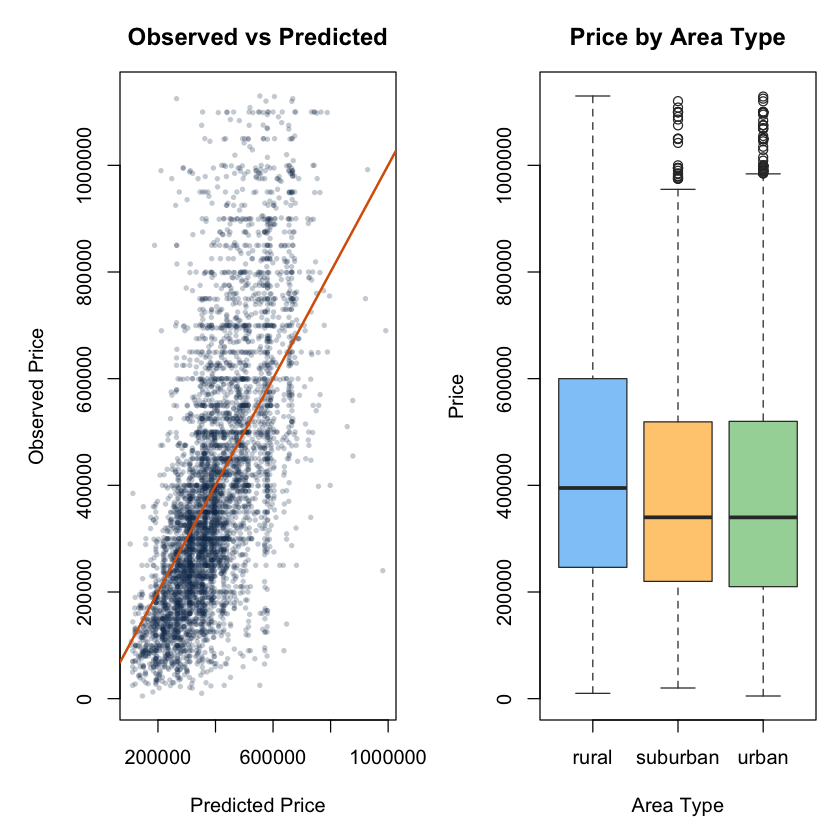

In [477]:
# 8: Create baseline regression plots

plot_sample_size <- min(5000, nrow(compact_training_data))
set.seed(123)
plot_index <- sample(seq_len(nrow(compact_training_data)), plot_sample_size)
multiple_plot_data <- compact_training_data[plot_index, ]
multiple_plot_predictions <- predict(multiple_regression_model, newdata = multiple_plot_data)

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))

plot(
  x = multiple_plot_predictions,
  y = multiple_plot_data$price,
  pch = 16,
  cex = 0.6,
  col = rgb(18/255, 53/255, 91/255, 0.25),
  xlab = "Predicted Price",
  ylab = "Observed Price",
  main = "Observed vs Predicted"
)
abline(0, 1, col = "#D95F02", lwd = 2)

boxplot(
  price ~ area_type,
  data = multiple_plot_data,
  col = c("#90CAF9", "#FFCC80", "#A5D6A7"),
  border = "#333333",
  main = "Price by Area Type",
  xlab = "Area Type",
  ylab = "Price"
)
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 9. Interactions</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    An <b>interaction</b> allows the effect of one predictor to depend on the value of another predictor. This is useful when the combined effect of two variables is not well captured by a purely additive model.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/interaction_regression_formula.svg" alt="Interaction regression formula" style="max-width: 100%; width: 820px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>Interactions can capture combined effects that an additive model misses.</li>
    <li>They may improve predictive accuracy when the relationship is not purely additive.</li>
    <li>They help explain how one variable changes the effect of another.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>Too many interactions reduce interpretability very quickly.</li>
    <li>They can increase multicollinearity and inflate standard errors.</li>
    <li>They make model selection more computationally expensive.</li>
  </ul>
  <div style="background: #FFF7ED; border: 1px solid #FDBA74; border-left: 6px solid #F97316; padding: 12px 14px; border-radius: 10px; margin-top: 12px;">
    <p style="margin: 0; font-size: 15px; color: #7C2D12; line-height: 1.7;">
      Recommended interaction set for this project: <b>4 interactions</b>. We will test <b>bed:bath</b>, <b>bath:house_size</b>, <b>bed:house_size</b>, and <b>acre_lot:area_type</b>. These are plausible and interpretable without making the model unwieldy.
    </p>
  </div>
</div>


In [478]:
# 9: Fit the interaction regression model

interaction_formula <- price ~ bed + bath + acre_lot + state + house_size + area_type +
  bed:bath + bath:house_size + bed:house_size + acre_lot:area_type

interaction_model <- lm(interaction_formula, data = compact_training_data)

interaction_train_predictions <- predict(interaction_model, newdata = compact_training_data)
interaction_test_predictions <- predict(interaction_model, newdata = compact_testing_data)

interaction_train_mse <- mean((compact_training_data$price - interaction_train_predictions)^2)
interaction_test_mse <- mean((compact_testing_data$price - interaction_test_predictions)^2)
interaction_train_rmse <- sqrt(interaction_train_mse)
interaction_test_rmse <- sqrt(interaction_test_mse)
interaction_train_r2 <- 1 - sum((compact_training_data$price - interaction_train_predictions)^2) / sum((compact_training_data$price - mean(compact_training_data$price))^2)
interaction_test_r2 <- 1 - sum((compact_testing_data$price - interaction_test_predictions)^2) / sum((compact_testing_data$price - mean(compact_testing_data$price))^2)

interaction_metrics <- data.frame(
  Dataset = c("Training", "Testing"),
  MSE = c(interaction_train_mse, interaction_test_mse),
  RMSE = c(interaction_train_rmse, interaction_test_rmse),
  R_Squared = c(interaction_train_r2, interaction_test_r2),
  stringsAsFactors = FALSE
)

interaction_formula_table <- data.frame(
  Model = "Interaction regression",
  Formula = deparse(interaction_formula),
  stringsAsFactors = FALSE
)

interaction_model_summary <- summary(interaction_model)
interaction_coefficients <- data.frame(
  Term = rownames(interaction_model_summary$coefficients),
  interaction_model_summary$coefficients,
  check.names = FALSE
)
interaction_coefficients <- interaction_coefficients[, c("Term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]
rownames(interaction_coefficients) <- NULL

interaction_coefficients_display <- interaction_coefficients
interaction_coefficients_display$Estimate <- round(interaction_coefficients_display$Estimate, 3)
interaction_coefficients_display$`Std. Error` <- round(interaction_coefficients_display$`Std. Error`, 3)
interaction_coefficients_display$`t value` <- round(interaction_coefficients_display$`t value`, 3)
interaction_coefficients_display$`Pr(>|t|)` <- ifelse(
  interaction_coefficients_display$`Pr(>|t|)` < 2.2e-16,
  "< 2.2e-16",
  formatC(interaction_coefficients_display$`Pr(>|t|)`, format = "e", digits = 3)
)

interaction_formula_table
interaction_metrics
head(interaction_coefficients_display, 20)
interaction_model_summary


Model,Formula
<chr>,<chr>
Interaction regression,price ~ bed + bath + acre_lot + state + house_size + area_type +
Interaction regression,bed:bath + bath:house_size + bed:house_size + acre_lot:area_type


Dataset,MSE,RMSE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>
Training,31862511181,178500.7,0.4024955
Testing,30473510483,174566.6,0.4281160


,Term,Estimate,Std. Error,t value,Pr(>|t|)
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,(Intercept),72834.427,1648.338,44.187,< 2.2e-16
2,bed,22349.117,208.533,107.173,< 2.2e-16
3,bath,81110.147,192.002,422.445,< 2.2e-16
4,acre_lot,-2.169,0.237,-9.170,< 2.2e-16
5,stateAlaska,116725.942,6940.223,16.819,< 2.2e-16
6,stateArizona,166041.921,1732.155,95.859,< 2.2e-16
7,stateArkansas,-10723.529,2348.791,-4.566,4.982e-06
8,stateCalifornia,343021.077,1566.440,218.981,< 2.2e-16
9,stateColorado,236820.070,2038.009,116.202,< 2.2e-16



Call:
lm(formula = interaction_formula, data = compact_training_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-36907923   -108502    -28249     78996    967373 

Coefficients:
                                Estimate    Std. Error  t value
(Intercept)                 72834.426552   1648.338295   44.187
bed                         22349.117127    208.532750  107.173
bath                        81110.146635    192.001631  422.445
acre_lot                       -2.169113      0.236552   -9.170
stateAlaska                116725.942024   6940.223148   16.819
stateArizona               166041.921119   1732.154571   95.859
stateArkansas              -10723.528620   2348.790808   -4.566
stateCalifornia            343021.076802   1566.440281  218.981
stateColorado              236820.070252   2038.008614  116.202
stateConnecticut            88095.139629   2426.249765   36.309
stateDelaware               91454.680407   2839.410820   32.209
stateDistrict of Columbia  39847

<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    The interaction model improves on the baseline multiple regression. The training RMSE falls from about <b>$182,242</b> to about <b>$178,501</b>, and the testing RMSE falls from about <b>$177,711</b> to about <b>$174,567</b>. The testing R<sup>2</sup> also increases from about <b>0.407</b> to about <b>0.428</b>. This means the interaction terms are capturing meaningful structure rather than only making the model more complicated.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The strongest interaction signals are economically informative. <b>bed:bath</b> is negative, about <b>-282.1</b>, with a standard error near <b>1.51</b> and a very large t-statistic near <b>-186.3</b>. That tells us the joint effect of bedrooms and bathrooms is not purely additive. <b>bath:house_size</b> is also negative, around <b>-0.643</b>, with a t-statistic near <b>-86.1</b>, which suggests that the marginal price effect of extra size changes depending on the number of bathrooms.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The interaction <b>acre_lot:area_typeurban</b> is strongly positive, at about <b>224,920</b>, with a very large t-statistic near <b>61.1</b>. This is an important substantive result: the contribution of lot size to price is very different in urban areas than in the reference area type. The <b>bed:house_size</b> interaction is smaller, but still significant, so square footage and bedroom count also work together rather than independently.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    At the model level, the results remain very strong. The <b>F-statistic</b> is approximately <b>1.161 × 10<sup>4</sup></b> with an essentially zero p-value, so the full interaction model is highly significant overall. The <b>Residual Standard Error (RSE)</b> is about <b>$178,500</b>, which is lower than in the baseline model and therefore reflects a meaningful reduction in residual noise. As before, the sample size is so large that many p-values are extremely small, so the most useful interpretation is whether the interactions lower testing error in a noticeable way. In this step, they do.
  </p>
</div>


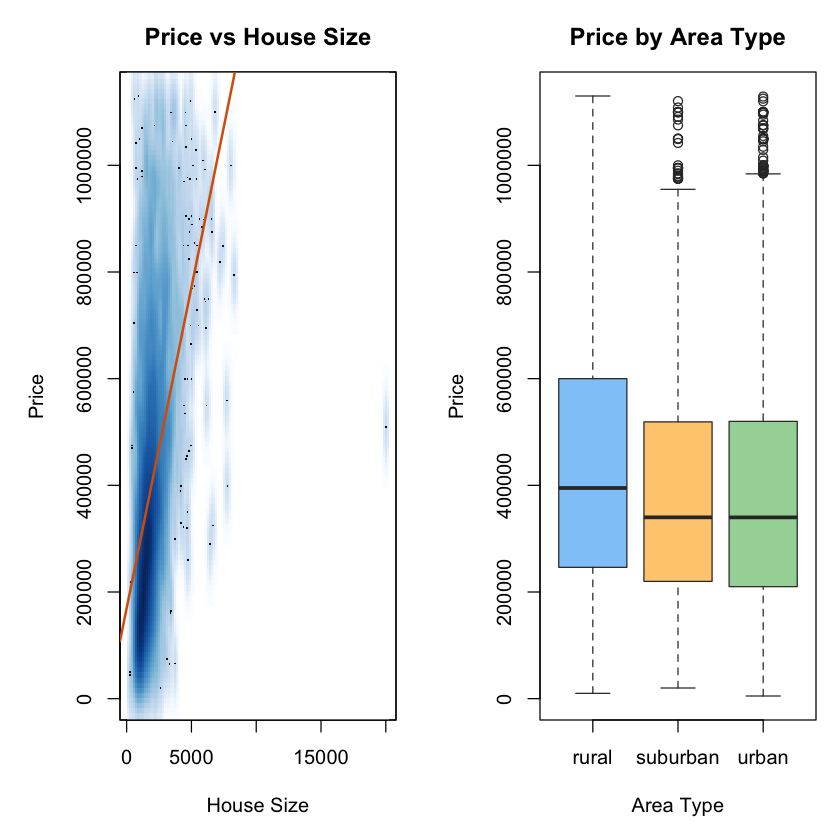

In [479]:
# 9: Create interaction plots

plot_sample_size <- min(5000, nrow(compact_training_data))
set.seed(123)
plot_index <- sample(seq_len(nrow(compact_training_data)), plot_sample_size)
interaction_plot_data <- compact_training_data[plot_index, ]

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))

smoothScatter(
  x = interaction_plot_data$house_size,
  y = interaction_plot_data$price,
  xlab = "House Size",
  ylab = "Price",
  main = "Price vs House Size"
)
abline(lm(price ~ house_size, data = interaction_plot_data), col = "#D95F02", lwd = 2)

boxplot(
  price ~ area_type,
  data = interaction_plot_data,
  col = c("#90CAF9", "#FFCC80", "#A5D6A7"),
  border = "#333333",
  main = "Price by Area Type",
  xlab = "Area Type",
  ylab = "Price"
)
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Interaction Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Price vs House Size</b> plot, each point cloud region represents many properties, and the orange line shows the overall linear trend. The upward slope confirms that larger homes tend to have higher prices, but the wide vertical spread also tells us that <b>size alone is not enough</b> to explain price. Properties with similar square footage can still have very different prices because location, bathrooms, lot size, and housing context also matter. That visual pattern supports the use of interaction terms, because the effect of size likely changes across different property profiles.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Price by Area Type</b> boxplot, we compare the distribution of prices across rural, suburban, and urban properties. The median line, the height of the box, and the whiskers tell us whether price levels differ systematically across area types. If the medians are separated and the spreads are not identical, then <b>area type is not just shifting the intercept</b>; it may also change how other variables behave. That is especially relevant for the interaction term between <b>acre_lot</b> and <b>area_type</b>, because land can carry a different price effect depending on whether the property is urban, suburban, or rural.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 10. Power Terms</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    We now test whether a polynomial power expansion improves the linear relationship for the predictor that is most likely to benefit from curvature. For this project, <b>house_size</b> is the best candidate because it is continuous, economically meaningful, and much more plausible for nonlinear effects than discrete variables such as <b>bed</b> or <b>bath</b>.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/power_regression_formula.svg" alt="Power regression formula" style="max-width: 100%; width: 820px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>Power terms can capture curvature while staying inside a regression framework.</li>
    <li>They are easy to compare degree by degree.</li>
    <li>They help us test whether a single predictor needs a nonlinear shape.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>High-degree polynomials can become unstable and hard to interpret.</li>
    <li>They may overfit the training data.</li>
    <li>The fitted shape can oscillate at the boundaries.</li>
  </ul>
</div>


In [480]:
# 10: Fit polynomial power models for house_size from degree 2 to degree 10

power_degrees <- 2:10
power_results <- data.frame()
power_models <- list()

for (d in power_degrees) {
  current_formula <- as.formula(
    paste0("price ~ bed + bath + acre_lot + state + area_type + poly(house_size, ", d, ", raw = TRUE)")
  )
  current_model <- lm(current_formula, data = compact_training_data)
  power_models[[as.character(d)]] <- current_model

  train_pred <- predict(current_model, newdata = compact_training_data)
  test_pred <- predict(current_model, newdata = compact_testing_data)

  train_mse <- mean((compact_training_data$price - train_pred)^2)
  test_mse <- mean((compact_testing_data$price - test_pred)^2)
  train_rmse <- sqrt(train_mse)
  test_rmse <- sqrt(test_mse)
  train_r2 <- 1 - sum((compact_training_data$price - train_pred)^2) / sum((compact_training_data$price - mean(compact_training_data$price))^2)
  test_r2 <- 1 - sum((compact_testing_data$price - test_pred)^2) / sum((compact_testing_data$price - mean(compact_testing_data$price))^2)

  power_results <- rbind(
    power_results,
    data.frame(
      Degree = d,
      Train_MSE = train_mse,
      Test_MSE = test_mse,
      Train_RMSE = train_rmse,
      Test_RMSE = test_rmse,
      Train_R_Squared = train_r2,
      Test_R_Squared = test_r2,
      stringsAsFactors = FALSE
    )
  )
}

best_power_degree <- power_results$Degree[which.min(power_results$Test_MSE)]
best_power_model <- power_models[[as.character(best_power_degree)]]
best_power_summary <- summary(best_power_model)
best_power_coefficients <- data.frame(
  Term = rownames(best_power_summary$coefficients),
  best_power_summary$coefficients,
  check.names = FALSE
)
best_power_coefficients <- best_power_coefficients[, c("Term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]
rownames(best_power_coefficients) <- NULL

best_power_coefficients_display <- best_power_coefficients
best_power_coefficients_display$Estimate <- round(best_power_coefficients_display$Estimate, 3)
best_power_coefficients_display$`Std. Error` <- round(best_power_coefficients_display$`Std. Error`, 3)
best_power_coefficients_display$`t value` <- round(best_power_coefficients_display$`t value`, 3)
best_power_coefficients_display$`Pr(>|t|)` <- ifelse(
  best_power_coefficients_display$`Pr(>|t|)` < 2.2e-16,
  "< 2.2e-16",
  formatC(best_power_coefficients_display$`Pr(>|t|)`, format = "e", digits = 3)
)

best_power_table <- data.frame(
  Selected_Degree = best_power_degree,
  stringsAsFactors = FALSE
)

power_results
best_power_table
head(best_power_coefficients_display, 20)
best_power_summary


Degree,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_R_Squared,Test_R_Squared
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,32453433968,31030999467,180148.4,176156.2,0.3914141,0.4176539
3,31063611570,30535744365,176248.7,174744.8,0.4174769,0.4269481
4,29315400587,29143939765,171217.4,170716.0,0.4502604,0.4530675
5,28598900393,28413924526,169112.1,168564.3,0.4636966,0.4667674
6,28250492235,28024278368,168078.8,167404.5,0.4702302,0.4740798
7,27644987192,27397689487,166267.8,165522.5,0.4815849,0.4858387
8,27351193536,27267049934,165382.0,165127.4,0.4870943,0.4882904
9,27211212275,27026997183,164958.2,164398.9,0.4897193,0.4927953
10,27034215597,26718116333,164420.8,163456.8,0.4930385,0.4985920


Selected_Degree
<int>
10


,Term,Estimate,Std. Error,t value,Pr(>|t|)
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,(Intercept),5929.399,1504.827,3.940,8.140e-05
2,bed,-19979.630,164.275,-121.623,< 2.2e-16
3,bath,36279.273,186.909,194.101,< 2.2e-16
4,acre_lot,-1.758,0.218,-8.070,7.046e-16
5,stateAlaska,129526.700,6392.629,20.262,< 2.2e-16
6,stateArizona,162402.181,1595.007,101.819,< 2.2e-16
7,stateArkansas,-10910.605,2163.258,-5.044,4.569e-07
8,stateCalifornia,361559.693,1442.968,250.567,< 2.2e-16
9,stateColorado,206388.650,1877.944,109.901,< 2.2e-16



Call:
lm(formula = current_formula, data = compact_training_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-16522413    -97181    -20853     71142   2913402 

Coefficients:
                                                                                        Estimate
(Intercept)                          5929.398508206480983062647283077239990234375000000000000000
bed                                -19979.630214731296291574835777282714843750000000000000000000
bath                                36279.272808033834735397249460220336914062500000000000000000
acre_lot                               -1.758377456461209575877546740230172872543334960937500000
stateAlaska                        129526.700489598981221206486225128173828125000000000000000000
stateArizona                       162402.180729911051457747817039489746093750000000000000000000
stateArkansas                      -10910.604956824039618368260562419891357421875000000000000000
stateCalifornia             

<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    This step reveals a much stronger nonlinear pattern for <b>house_size</b> than the baseline model captured. In the current run, the <b>best polynomial degree is 10</b>, because it produces the lowest testing error among the models we evaluated. The testing MSE falls from about <b>31.58 billion</b> in the linear baseline to about <b>26.72 billion</b> at degree 10, while the testing RMSE improves from about <b>$177,711</b> to about <b>$163,457</b>. The testing R<sup>2</sup> also rises from about <b>0.407</b> to about <b>0.499</b>. That is a meaningful predictive gain, so a straight-line size effect is clearly too restrictive for this dataset.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    Another important result is that the testing error does <b>not</b> increase within the degrees we tried. Instead, the testing MSE keeps decreasing from degree 1 through degree 10. That means we do <b>not</b> yet see overfitting inside this range; rather, the original linear model was underfitting the size effect. The coefficient table should therefore be read with caution, because the polynomial terms are working together to approximate one curved relationship rather than acting as separate interpretable effects.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The graphs reinforce the same point. In the <b>training vs testing MSE</b> plot, both curves move downward as the degree increases, and the gap between them does not blow up, so we do not see strong evidence of overfitting within the tested range. In the <b>test R<sup>2</sup></b> plot, the fit improves steadily and peaks at degree 10. Together, those two visuals show that <b>house_size needs a curved functional form</b> and that later flexible methods are worth comparing against this strong polynomial benchmark.
  </p>
</div>


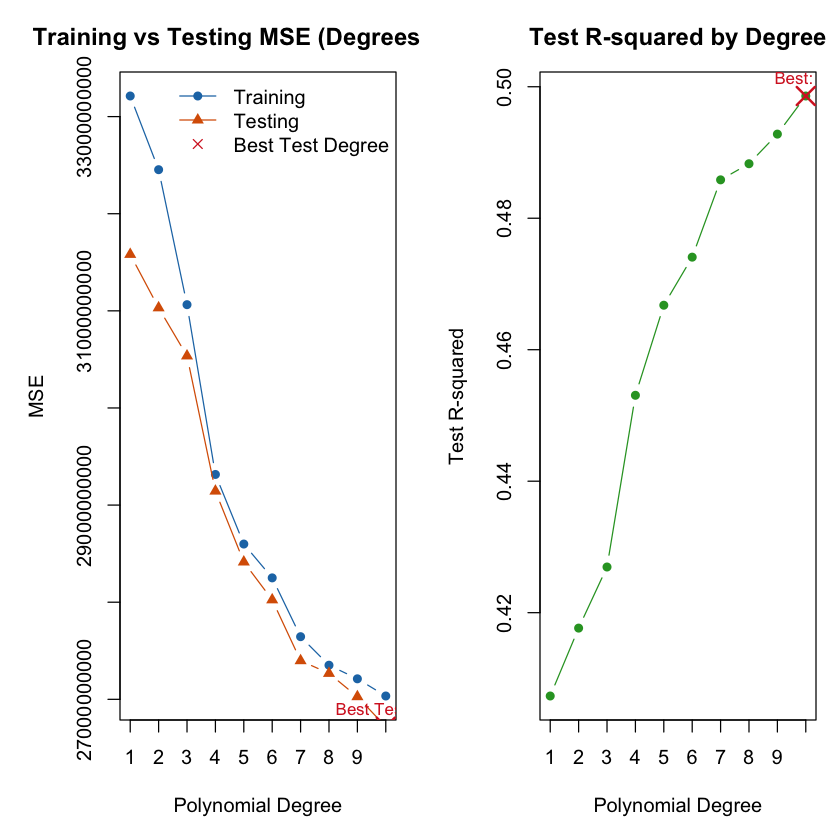

In [481]:
# 10: Plot polynomial degree performance

power_results_plot <- rbind(
  data.frame(
    Degree = 1,
    Train_MSE = multiple_train_mse,
    Test_MSE = multiple_test_mse,
    Train_RMSE = multiple_train_rmse,
    Test_RMSE = multiple_test_rmse,
    Train_R_Squared = multiple_train_r2,
    Test_R_Squared = multiple_test_r2,
    stringsAsFactors = FALSE
  ),
  power_results
)

best_power_degree_plot <- power_results_plot$Degree[which.min(power_results_plot$Test_MSE)]

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))

plot(
  power_results_plot$Degree,
  power_results_plot$Train_MSE,
  type = "b",
  pch = 16,
  col = "#1F77B4",
  xlab = "Polynomial Degree",
  ylab = "MSE",
  main = "Training vs Testing MSE (Degrees 1-10)",
  xaxt = "n"
)
axis(1, at = 1:10, labels = 1:10)
lines(power_results_plot$Degree, power_results_plot$Test_MSE, type = "b", pch = 17, col = "#D95F02")
points(best_power_degree_plot, power_results_plot$Test_MSE[power_results_plot$Degree == best_power_degree_plot], pch = 4, cex = 2, lwd = 2, col = "#D62728")
text(best_power_degree_plot, power_results_plot$Test_MSE[power_results_plot$Degree == best_power_degree_plot], labels = paste0("Best Test: ", best_power_degree_plot), pos = 3, cex = 0.85, col = "#D62728")
legend("topright", legend = c("Training", "Testing", "Best Test Degree"), col = c("#1F77B4", "#D95F02", "#D62728"), pch = c(16, 17, 4), lty = c(1, 1, NA), bty = "n")

plot(
  power_results_plot$Degree,
  power_results_plot$Test_R_Squared,
  type = "b",
  pch = 16,
  col = "#2CA02C",
  xlab = "Polynomial Degree",
  ylab = "Test R-squared",
  main = "Test R-squared by Degree",
  xaxt = "n"
)
axis(1, at = 1:10, labels = 1:10)
points(best_power_degree_plot, power_results_plot$Test_R_Squared[power_results_plot$Degree == best_power_degree_plot], pch = 4, cex = 2, lwd = 2, col = "#D62728")
text(best_power_degree_plot, power_results_plot$Test_R_Squared[power_results_plot$Degree == best_power_degree_plot], labels = paste0("Best: ", best_power_degree_plot), pos = 3, cex = 0.85, col = "#D62728")
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Power-Term Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Training vs Testing MSE</b> plot, both curves measure prediction error across polynomial degree. Lower is better. The blue line tracks training error and the orange line tracks testing error. In this run, both move downward as the degree increases, and the testing curve reaches its minimum at <b>degree 10</b>. That shows that adding polynomial flexibility to <b>house_size</b> keeps improving predictive performance within the tested range.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Test R<sup>2</sup> by Degree</b> plot, higher is better. The steady upward pattern confirms the same message from a goodness-of-fit perspective: the nonlinear size effect is becoming more useful as the degree increases. Because the test curve improves rather than turning upward, these graphs suggest underfitting in the simpler models rather than obvious overfitting up to degree 10.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 11. Forward Stepwise Selection</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    <b>Forward stepwise selection</b> starts from the intercept-only model and adds predictors one at a time. At each step, it chooses the predictor that improves the chosen information criterion the most. In this notebook, we use <b>AIC</b> as the selection rule.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/stepwise_aic_formula.svg" alt="Stepwise AIC formula" style="max-width: 100%; width: 640px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It builds a simpler model gradually and is easy to explain.</li>
    <li>It can remove weak predictors without testing every possible subset.</li>
    <li>It is usually more computationally feasible than best subset selection.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It is greedy, so a locally good step is not always globally optimal.</li>
    <li>Its final model depends on the selection path and the criterion.</li>
    <li>It can still become unstable if many related predictors are competing.</li>
  </ul>
  <div style="background: #FFF7ED; border: 1px solid #FDBA74; border-left: 6px solid #F97316; padding: 12px 14px; border-radius: 10px; margin-top: 12px;">
    <p style="margin: 0; font-size: 15px; color: #7C2D12; line-height: 1.7;">
      To keep the advanced modeling steps computationally feasible, the remaining methods use a <b>shared compact training sample</b> and a <b>shared evaluation sample</b>. This keeps the comparison fair across models while still preserving the main structure of the dataset.
    </p>
  </div>
</div>


In [482]:
# 11: Prepare shared modeling samples and fit the forward stepwise model

suppressPackageStartupMessages({
  library(MASS)
  library(glmnet)
  library(splines)
  library(mgcv)
})

compute_regression_metrics <- function(actual, predicted) {
  data.frame(
    MSE = mean((actual - predicted)^2),
    RMSE = sqrt(mean((actual - predicted)^2)),
    MAE = mean(abs(actual - predicted)),
    R_Squared = 1 - sum((actual - predicted)^2) / sum((actual - mean(actual))^2),
    stringsAsFactors = FALSE
  )
}

most_common_level <- function(x) {
  names(sort(table(x), decreasing = TRUE))[1]
}

build_reference_grid <- function(source_data, x_values, x_name = "house_size") {
  grid <- data.frame(
    bed = median(source_data$bed, na.rm = TRUE),
    bath = median(source_data$bath, na.rm = TRUE),
    acre_lot = median(source_data$acre_lot, na.rm = TRUE),
    state = factor(most_common_level(source_data$state), levels = levels(source_data$state)),
    area_type = factor(most_common_level(source_data$area_type), levels = levels(source_data$area_type)),
    house_size = x_values
  )
  names(grid)[names(grid) == "house_size"] <- x_name
  grid
}

safe_loess_predict <- function(model, x_values) {
  prediction <- as.numeric(predict(model, newdata = data.frame(house_size = x_values)))
  if (any(is.na(prediction))) {
    fitted_x <- model$x
    fitted_y <- fitted(model)
    prediction[is.na(prediction)] <- approx(
      x = fitted_x,
      y = fitted_y,
      xout = x_values[is.na(prediction)],
      rule = 2
    )$y
  }
  prediction
}

knn_regression_predict <- function(train_x, train_y, test_x, k, chunk_size = 150) {
  train_matrix <- as.matrix(train_x)
  test_matrix <- as.matrix(test_x)
  k_effective <- min(k, nrow(train_matrix))
  train_sq <- rowSums(train_matrix^2)
  predictions <- numeric(nrow(test_matrix))

  for (start_index in seq(1, nrow(test_matrix), by = chunk_size)) {
    end_index <- min(start_index + chunk_size - 1, nrow(test_matrix))
    chunk <- test_matrix[start_index:end_index, , drop = FALSE]
    chunk_sq <- rowSums(chunk^2)
    distance_matrix <- outer(chunk_sq, train_sq, "+") - 2 * chunk %*% t(train_matrix)
    distance_matrix <- pmax(distance_matrix, 0)
    neighbor_index <- t(apply(distance_matrix, 1, function(row) head(order(row), k_effective)))
    predictions[start_index:end_index] <- rowMeans(matrix(train_y[neighbor_index], nrow = nrow(neighbor_index)))
  }

  predictions
}

if (!exists("moderate_training_data")) {
  set.seed(123)
  moderate_training_size <- min(60000, nrow(compact_training_data))
  moderate_training_index <- sample(seq_len(nrow(compact_training_data)), moderate_training_size)
  moderate_training_data <- compact_training_data[moderate_training_index, ]

  local_training_size <- min(15000, nrow(compact_training_data))
  local_training_index <- sample(seq_len(nrow(compact_training_data)), local_training_size)
  local_training_data <- compact_training_data[local_training_index, ]

  comparison_eval_size <- min(3000, nrow(compact_training_data), nrow(compact_testing_data))
  comparison_training_index <- sample(seq_len(nrow(compact_training_data)), comparison_eval_size)
  comparison_testing_index <- sample(seq_len(nrow(compact_testing_data)), comparison_eval_size)
  comparison_training_eval <- compact_training_data[comparison_training_index, ]
  comparison_testing_eval <- compact_testing_data[comparison_testing_index, ]
}

if (!exists("regression_model_registry")) {
  regression_model_registry <- list()
}

selection_candidate_formula <- price ~ bed + bath + acre_lot + state + house_size + area_type
forward_null_model <- lm(price ~ 1, data = moderate_training_data)

forward_stepwise_model <- stepAIC(
  object = forward_null_model,
  scope = list(lower = price ~ 1, upper = selection_candidate_formula),
  direction = "forward",
  trace = FALSE
)

forward_train_predictions <- predict(forward_stepwise_model, newdata = comparison_training_eval)
forward_test_predictions <- predict(forward_stepwise_model, newdata = comparison_testing_eval)

forward_metrics <- rbind(
  data.frame(Dataset = "Training", compute_regression_metrics(comparison_training_eval$price, forward_train_predictions)),
  data.frame(Dataset = "Testing", compute_regression_metrics(comparison_testing_eval$price, forward_test_predictions))
)

forward_selected_terms <- attr(terms(forward_stepwise_model), "term.labels")
forward_selected_table <- data.frame(
  Selected_Term = if (length(forward_selected_terms) == 0) "Intercept only" else forward_selected_terms,
  stringsAsFactors = FALSE
)

forward_path_table <- data.frame(forward_stepwise_model$anova)
forward_path_table$Step_Number <- seq_len(nrow(forward_path_table))

regression_model_registry[["Forward Stepwise"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = forward_train_predictions,
  test_actual = comparison_testing_eval$price,
  test_pred = forward_test_predictions
)

forward_selected_table
forward_metrics
forward_path_table
summary(forward_stepwise_model)


Selected_Term
<chr>
bath
state
area_type
house_size
bed
acre_lot


Dataset,MSE,RMSE,MAE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Training,28410763627,168554.9,125453.4,0.4417580
Testing,32905058833,181397.5,131737.0,0.3887341


Step,Df,Deviance,Resid..Df,Resid..Dev,AIC,Step_Number
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
,NA,NA,59999,3195243946036938,1481902,1
+ bath,1,686436155845316,59998,2508807790191622,1467393,2
+ state,53,691173513820323,59945,1817634276371299,1448163,3
+ area_type,2,22821095722203,59943,1794813180649096,1447409,4
+ house_size,1,2039700862969,59942,1792773479786127,1447342,5
+ bed,1,1700564164060,59941,1791072915622067,1447287,6
+ acre_lot,1,83662584284,59940,1790989253037783,1447287,7



Call:
lm(formula = price ~ bath + state + area_type + house_size + 
    bed + acre_lot, data = moderate_training_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-2461961  -107026   -23459    79269   902784 

Coefficients:
                             Estimate  Std. Error t value             Pr(>|t|)
(Intercept)                45066.5385   6771.0864   6.656 0.000000000028431254
bath                      112320.0235    943.6349 119.029 < 0.0000000000000002
stateAlaska               187451.9654  28685.5866   6.535 0.000000000064242259
stateArizona              177246.9779   7161.2735  24.751 < 0.0000000000000002
stateArkansas               1160.9513   9820.0180   0.118              0.90589
stateCalifornia           346273.8637   6504.8383  53.233 < 0.0000000000000002
stateColorado             237358.6065   8456.3971  28.069 < 0.0000000000000002
stateConnecticut           82097.0443  10066.2527   8.156 0.000000000000000354
stateDelaware             104310.4464  11964.9622 

<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    Forward stepwise selection identifies a very clear linear structure. The AIC path adds predictors in the order <b>bath</b>, <b>state</b>, <b>area_type</b>, <b>house_size</b>, <b>bed</b>, and finally <b>acre_lot</b>. This tells us that bathroom count and location deliver the strongest early gains, while lot size contributes only a very small final improvement.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In predictive terms, the model is acceptable but not leading. Its training RMSE is about <b>$168,555</b> and its testing RMSE is about <b>$181,398</b>, with a testing R<sup>2</sup> near <b>0.389</b>. So forward stepwise gives us a cleaner linear benchmark, but it is clearly weaker than the strongest nonlinear models. The fact that AIC barely changes when <b>acre_lot</b> enters also suggests that the model had already captured most of the useful linear structure before that final step.
  </p>
</div>


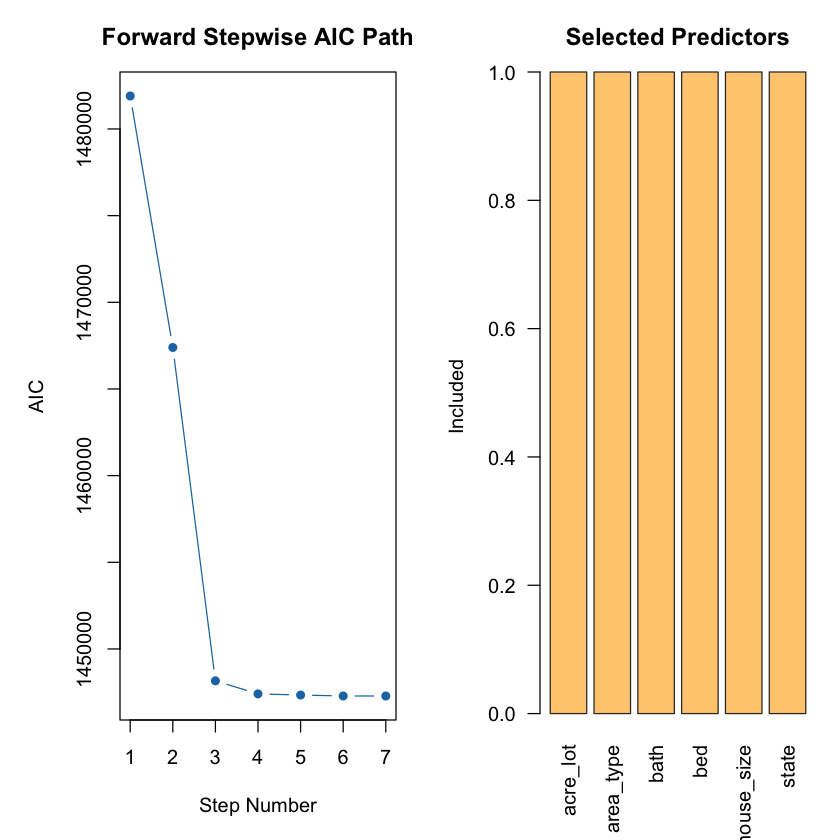

In [483]:
# 11: Plot the forward stepwise selection path

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))

plot(
  forward_path_table$Step_Number,
  forward_path_table$AIC,
  type = "b",
  pch = 16,
  col = "#1F77B4",
  xlab = "Step Number",
  ylab = "AIC",
  main = "Forward Stepwise AIC Path"
)

barplot(
  table(forward_selected_table$Selected_Term),
  col = "#FFCC80",
  border = "#333333",
  las = 2,
  main = "Selected Predictors",
  ylab = "Included"
)

par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Forward Stepwise Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Forward Stepwise AIC Path</b> plot, lower AIC means a better balance between fit and model complexity. As the model adds predictors, the curve should fall sharply at first and then flatten out. That is exactly the pattern to watch: once the decreases become very small, the next variables are adding limited value.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Selected Predictors</b> bar chart, each bar marks a predictor retained in the final model. The important point is which variables survive the selection process. Here the final set is compact and intuitive, which makes forward stepwise useful as a linear benchmark, even though it is not one of the strongest predictive models overall.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 12. Backward Stepwise Selection</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    <b>Backward stepwise selection</b> starts from the full candidate model and removes predictors one at a time. At each step, it drops the term whose removal leads to the best improvement in the information criterion. We again use <b>AIC</b> as the rule.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/stepwise_aic_formula.svg" alt="Backward stepwise AIC formula" style="max-width: 100%; width: 640px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It starts from the richest linear model and then simplifies.</li>
    <li>It can reveal which predictors contribute the least after adjustment.</li>
    <li>It is often more stable than blindly testing many complex combinations.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It still depends on a greedy path and may miss the globally best subset.</li>
    <li>Its result depends on the candidate model we start from.</li>
    <li>Highly related variables can make the selection path unstable.</li>
  </ul>
</div>


In [484]:
# 12: Fit the backward stepwise model

backward_full_model <- lm(selection_candidate_formula, data = moderate_training_data)

backward_stepwise_model <- stepAIC(
  object = backward_full_model,
  direction = "backward",
  trace = FALSE
)

backward_train_predictions <- predict(backward_stepwise_model, newdata = comparison_training_eval)
backward_test_predictions <- predict(backward_stepwise_model, newdata = comparison_testing_eval)

backward_metrics <- rbind(
  data.frame(Dataset = "Training", compute_regression_metrics(comparison_training_eval$price, backward_train_predictions)),
  data.frame(Dataset = "Testing", compute_regression_metrics(comparison_testing_eval$price, backward_test_predictions))
)

backward_selected_terms <- attr(terms(backward_stepwise_model), "term.labels")
backward_selected_table <- data.frame(
  Selected_Term = if (length(backward_selected_terms) == 0) "Intercept only" else backward_selected_terms,
  stringsAsFactors = FALSE
)

backward_path_table <- data.frame(backward_stepwise_model$anova)
backward_path_table$Step_Number <- seq_len(nrow(backward_path_table))

regression_model_registry[["Backward Stepwise"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = backward_train_predictions,
  test_actual = comparison_testing_eval$price,
  test_pred = backward_test_predictions
)

backward_selected_table
backward_metrics
backward_path_table
summary(backward_stepwise_model)


Selected_Term
<chr>
bed
bath
acre_lot
state
house_size
area_type


Dataset,MSE,RMSE,MAE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Training,28410763627,168554.9,125453.4,0.4417580
Testing,32905058833,181397.5,131737.0,0.3887341


Step,Df,Deviance,Resid..Df,Resid..Dev,AIC,Step_Number
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
,NA,NA,59940,1790989253037793,1447287,1



Call:
lm(formula = price ~ bed + bath + acre_lot + state + house_size + 
    area_type, data = moderate_training_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-2461961  -107026   -23459    79269   902784 

Coefficients:
                             Estimate  Std. Error t value             Pr(>|t|)
(Intercept)                45066.5385   6771.0864   6.656 0.000000000028431254
bed                         6335.1027    839.0248   7.551 0.000000000000043953
bath                      112320.0235    943.6349 119.029 < 0.0000000000000002
acre_lot                      -1.8479      1.1043  -1.673              0.09427
stateAlaska               187451.9654  28685.5866   6.535 0.000000000064242259
stateArizona              177246.9779   7161.2735  24.751 < 0.0000000000000002
stateArkansas               1160.9513   9820.0180   0.118              0.90589
stateCalifornia           346273.8637   6504.8383  53.233 < 0.0000000000000002
stateColorado             237358.6065   8456.3971 

<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    Backward stepwise selection ends in the <b>same final model</b> as forward stepwise: <b>bed</b>, <b>bath</b>, <b>acre_lot</b>, <b>state</b>, <b>house_size</b>, and <b>area_type</b>. That is useful evidence, because when forward and backward searches converge to the same structure, it suggests that the selected linear specification is reasonably stable within the candidate set.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    Its performance is also identical in this run: training RMSE of about <b>$168,555</b>, testing RMSE of about <b>$181,398</b>, and testing R<sup>2</sup> near <b>0.389</b>. So the main lesson is not that backward is better than forward, but that both procedures point to the same simplified linear benchmark. That makes the result easier to defend, even though it remains weaker than the best nonlinear methods.
  </p>
</div>


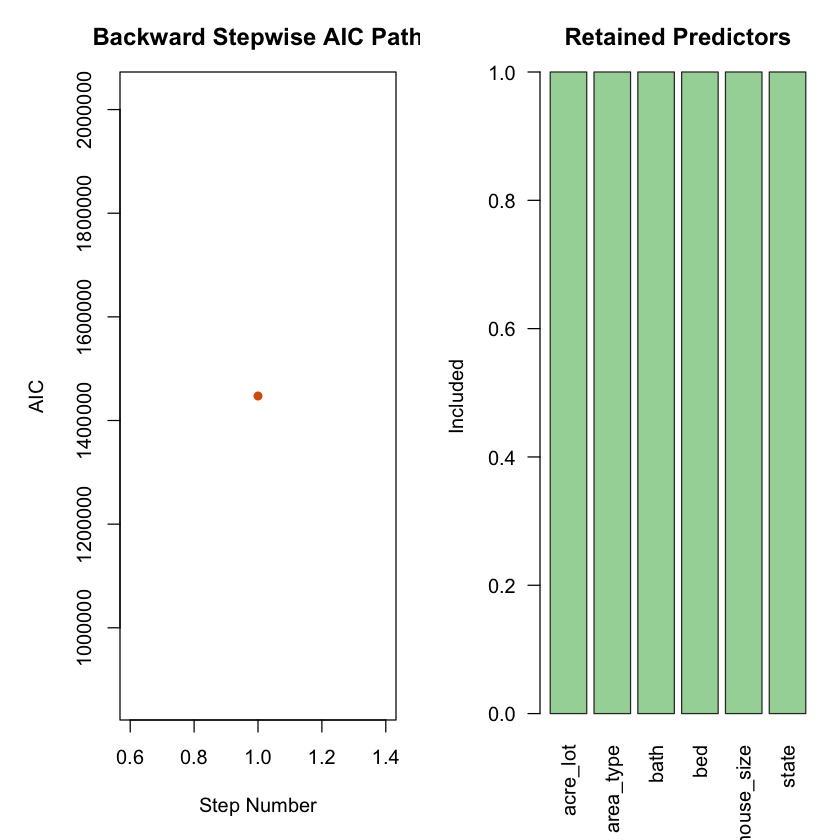

In [485]:
# 12: Plot the backward stepwise selection path

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))

plot(
  backward_path_table$Step_Number,
  backward_path_table$AIC,
  type = "b",
  pch = 16,
  col = "#D95F02",
  xlab = "Step Number",
  ylab = "AIC",
  main = "Backward Stepwise AIC Path"
)

barplot(
  table(backward_selected_table$Selected_Term),
  col = "#A5D6A7",
  border = "#333333",
  las = 2,
  main = "Retained Predictors",
  ylab = "Included"
)

par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Backward Stepwise Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Backward Stepwise AIC Path</b> plot, lower AIC is better. Because backward selection starts from the richest model, the curve shows whether removing predictors simplifies the model without losing too much fit. In this run, the path quickly settles into the same structure found by forward selection.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Retained Predictors</b> bar chart, every bar marks a predictor kept in the final model. The important takeaway is not the height, but which variables survive: the same core variables remain after the backward search, which reinforces the idea that the final linear benchmark is stable across selection direction.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 13. Ridge Regression</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    <b>Ridge regression</b> shrinks coefficient estimates toward zero by adding an <b>L2 penalty</b>. Unlike subset selection, ridge usually keeps all predictors in the model, but it reduces variance by shrinking unstable coefficients.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/ridge_formula_v2.svg" alt="Ridge regression formula" style="max-width: 100%; width: 980px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It reduces variance when predictors are correlated.</li>
    <li>It often improves predictive performance over ordinary least squares.</li>
    <li>It is stable when many coefficients compete with each other.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It shrinks coefficients but does not perform variable selection in the strict sense.</li>
    <li>Its coefficients are less directly interpretable than ordinary least squares.</li>
    <li>It requires choosing the tuning parameter <b>lambda</b>.</li>
  </ul>
</div>


In [486]:
# 13: Fit the ridge regression model

ridge_formula <- price ~ bed + bath + acre_lot + state + house_size + area_type
ridge_x_train <- model.matrix(ridge_formula, data = moderate_training_data)[, -1]
ridge_y_train <- moderate_training_data$price
ridge_x_train_eval <- model.matrix(ridge_formula, data = comparison_training_eval)[, -1]
ridge_x_test_eval <- model.matrix(ridge_formula, data = comparison_testing_eval)[, -1]

cv_ridge_model <- cv.glmnet(
  x = ridge_x_train,
  y = ridge_y_train,
  alpha = 0,
  nfolds = 5,
  standardize = TRUE
)

ridge_train_predictions <- as.numeric(predict(cv_ridge_model, newx = ridge_x_train_eval, s = "lambda.min"))
ridge_test_predictions <- as.numeric(predict(cv_ridge_model, newx = ridge_x_test_eval, s = "lambda.min"))

ridge_metrics <- rbind(
  data.frame(Dataset = "Training", compute_regression_metrics(comparison_training_eval$price, ridge_train_predictions)),
  data.frame(Dataset = "Testing", compute_regression_metrics(comparison_testing_eval$price, ridge_test_predictions))
)

ridge_coefficient_table <- data.frame(
  Term = rownames(as.matrix(coef(cv_ridge_model, s = "lambda.min"))),
  Coefficient = as.numeric(coef(cv_ridge_model, s = "lambda.min")),
  stringsAsFactors = FALSE
)

ridge_lambda_table <- data.frame(
  Lambda_Min = cv_ridge_model$lambda.min,
  Lambda_1SE = cv_ridge_model$lambda.1se,
  Nonzero_Coefficients = sum(abs(ridge_coefficient_table$Coefficient) > 0),
  stringsAsFactors = FALSE
)

regression_model_registry[["Ridge"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = ridge_train_predictions,
  test_actual = comparison_testing_eval$price,
  test_pred = ridge_test_predictions
)

ridge_lambda_table
ridge_metrics
head(ridge_coefficient_table[order(-abs(ridge_coefficient_table$Coefficient)), ], 20)


Lambda_Min,Lambda_1SE,Nonzero_Coefficients
<dbl>,<dbl>,<int>
1020992,15161410,60


Dataset,MSE,RMSE,MAE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Training,42597307200,206391.2,164274.5,0.1630071
Testing,45589424451,213516.8,166872.2,0.1531011


,Term,Coefficient
,<chr>,<dbl>
1,(Intercept),319216.96
8,stateCalifornia,43805.06
12,stateDistrict of Columbia,43051.67
16,stateHawaii,39307.74
50,stateUtah,30718.70
40,stateOhio,-29589.19
55,stateWest Virginia,-28944.25
54,stateWashington,27893.52
5,stateAlaska,27015.60


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In this project, ridge regression is <b>not competitive</b>. Its training RMSE is about <b>$207,657</b> and its testing RMSE is about <b>$214,705</b>, with a testing R<sup>2</sup> of only about <b>0.144</b>. Those values are much worse than the baseline multiple regression and far below the stronger nonlinear models.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The coefficient table helps explain why. Ridge keeps <b>all 60 expanded coefficients active</b>, so it shrinks the model but does not simplify it. The selected penalty reduces many state effects, but the resulting bias is too strong and predictive performance deteriorates. In short, this dataset benefits more from <b>flexible functional form</b> than from simple coefficient shrinkage.
  </p>
</div>


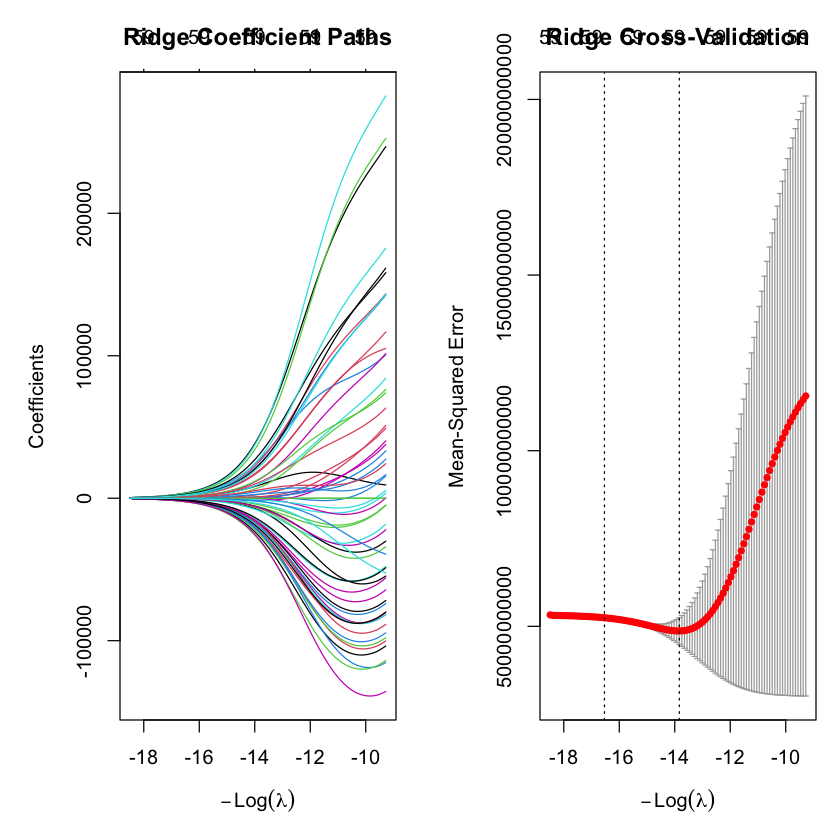

In [487]:
# 13: Plot ridge coefficient paths and cross-validation error

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))
plot(cv_ridge_model$glmnet.fit, xvar = "lambda", label = FALSE, main = "Ridge Coefficient Paths")
plot(cv_ridge_model, main = "Ridge Cross-Validation")
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Ridge Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Ridge Coefficient Paths</b> plot, each line is a coefficient trajectory as the penalty increases. Ridge shrinks coefficients toward zero, but unlike lasso it usually does <b>not</b> set them exactly to zero. So the visual pattern should look like continuous shrinkage rather than hard variable removal.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Ridge Cross-Validation</b> plot, the vertical selection marks the preferred penalty. In this run, the chosen lambda leads to poor testing performance, so the plot should be read as evidence that shrinkage alone is not solving the main problem. The model is becoming more regularized, but not more predictive than the stronger nonlinear approaches.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 14. Lasso Regression</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    <b>Lasso regression</b> uses an <b>L1 penalty</b>, which both shrinks coefficients and can set some of them exactly to zero. That makes lasso attractive when we want a model that is both predictive and more compact.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/lasso_formula_v2.svg" alt="Lasso regression formula" style="max-width: 100%; width: 980px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It can perform shrinkage and variable selection at the same time.</li>
    <li>It often gives a more compact final model than ridge.</li>
    <li>It can improve predictive performance when only part of the predictor set is truly important.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It can be unstable when groups of predictors are very correlated.</li>
    <li>The selected model depends on the tuning parameter <b>lambda</b>.</li>
    <li>Its coefficients are biased because of shrinkage.</li>
  </ul>
</div>


In [488]:
# 14: Fit the lasso regression model

lasso_formula <- ridge_formula
lasso_x_train <- ridge_x_train
lasso_y_train <- ridge_y_train
lasso_x_train_eval <- ridge_x_train_eval
lasso_x_test_eval <- ridge_x_test_eval

cv_lasso_model <- cv.glmnet(
  x = lasso_x_train,
  y = lasso_y_train,
  alpha = 1,
  nfolds = 5,
  standardize = TRUE
)

lasso_train_predictions <- as.numeric(predict(cv_lasso_model, newx = lasso_x_train_eval, s = "lambda.min"))
lasso_test_predictions <- as.numeric(predict(cv_lasso_model, newx = lasso_x_test_eval, s = "lambda.min"))

lasso_metrics <- rbind(
  data.frame(Dataset = "Training", compute_regression_metrics(comparison_training_eval$price, lasso_train_predictions)),
  data.frame(Dataset = "Testing", compute_regression_metrics(comparison_testing_eval$price, lasso_test_predictions))
)

lasso_coefficient_table <- data.frame(
  Term = rownames(as.matrix(coef(cv_lasso_model, s = "lambda.min"))),
  Coefficient = as.numeric(coef(cv_lasso_model, s = "lambda.min")),
  stringsAsFactors = FALSE
)

lasso_lambda_table <- data.frame(
  Lambda_Min = cv_lasso_model$lambda.min,
  Lambda_1SE = cv_lasso_model$lambda.1se,
  Nonzero_Coefficients = sum(abs(lasso_coefficient_table$Coefficient) > 0),
  stringsAsFactors = FALSE
)

regression_model_registry[["Lasso"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = lasso_train_predictions,
  test_actual = comparison_testing_eval$price,
  test_pred = lasso_test_predictions
)

lasso_lambda_table
lasso_metrics
head(lasso_coefficient_table[order(-abs(lasso_coefficient_table$Coefficient)), ], 20)


Lambda_Min,Lambda_1SE,Nonzero_Coefficients
<dbl>,<dbl>,<int>
80911.89,88800.7,2


Dataset,MSE,RMSE,MAE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Training,46207066392,214958.3,172051.6,0.09207910
Testing,49041505651,221453.2,174175.7,0.08897297


,Term,Coefficient
,<chr>,<dbl>
1,(Intercept),329392.66
3,bath,27507.13
2,bed,0.00
4,acre_lot,0.00
5,stateAlaska,0.00
6,stateArizona,0.00
7,stateArkansas,0.00
8,stateCalifornia,0.00
9,stateColorado,0.00


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    Lasso gives the <b>most compact</b> regularized model in this notebook, but it is also one of the weakest performers. Its testing RMSE is about <b>$221,453</b> and its testing R<sup>2</sup> is only about <b>0.089</b>, which is worse than ridge and much worse than the best flexible regression models.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The reason is clear in the coefficient table: at <b>lambda.min</b>, lasso effectively keeps only the intercept and <b>bath</b> as nonzero terms. That makes the model very easy to explain, but it also means the penalty is discarding too much useful information from location, size, and housing context. So in this dataset, lasso is a good example of sparsity, but it is <b>too aggressive</b> to be a strong final predictive model.
  </p>
</div>


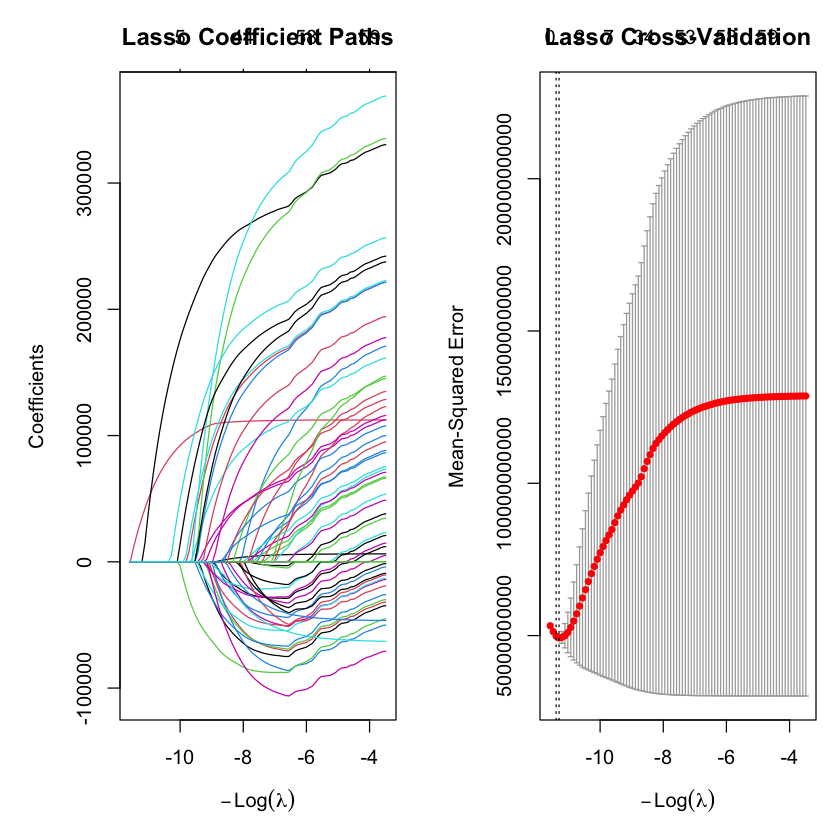

In [489]:
# 14: Plot lasso coefficient paths and cross-validation error

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))
plot(cv_lasso_model$glmnet.fit, xvar = "lambda", label = FALSE, main = "Lasso Coefficient Paths")
plot(cv_lasso_model, main = "Lasso Cross-Validation")
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Lasso Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Lasso Coefficient Paths</b> plot, each line is one coefficient traced as the penalty changes. The key visual feature is that lasso can drive coefficients <b>exactly to zero</b>. That is the graphical signature of variable selection.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Lasso Cross-Validation</b> plot, we look for the lambda with the lowest CV error. In this run, the selected model is very sparse, but the resulting prediction quality is poor. So the graphs tell a consistent story: lasso is doing what it is supposed to do mechanically, but the amount of shrinkage required here is too strong for this dataset and it throws away too much predictive information.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 15. Step Functions</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    A <b>step function</b> cuts a continuous predictor into intervals and fits a different mean level in each interval. This is a simple way to introduce nonlinearity without requiring a fully smooth curve.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/step_function_formula_v2.svg" alt="Step function formula" style="max-width: 100%; width: 860px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It is easy to explain because the predictor is divided into bins.</li>
    <li>It can capture broad nonlinear structure without assuming a specific polynomial shape.</li>
    <li>It is often a good first nonlinear baseline.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>The fitted function is not smooth at the cutpoints.</li>
    <li>Results depend on the chosen breaks.</li>
    <li>Fine detail inside a bin is lost.</li>
  </ul>
</div>


In [490]:
# 15: Fit the step-function model for house_size

step_breaks <- unique(quantile(moderate_training_data$house_size, probs = seq(0, 1, length.out = 6), na.rm = TRUE))
if (length(step_breaks) < 4) {
  step_breaks <- seq(min(moderate_training_data$house_size), max(moderate_training_data$house_size), length.out = 6)
}

step_training_data <- moderate_training_data
step_training_data$house_size_step <- cut(step_training_data$house_size, breaks = step_breaks, include.lowest = TRUE)
step_training_data$house_size_step <- factor(step_training_data$house_size_step)

step_training_eval <- comparison_training_eval
step_training_eval$house_size_step <- cut(step_training_eval$house_size, breaks = step_breaks, include.lowest = TRUE)
step_training_eval$house_size_step <- factor(step_training_eval$house_size_step, levels = levels(step_training_data$house_size_step))

step_testing_eval <- comparison_testing_eval
step_testing_eval$house_size_step <- cut(step_testing_eval$house_size, breaks = step_breaks, include.lowest = TRUE)
step_testing_eval$house_size_step <- factor(step_testing_eval$house_size_step, levels = levels(step_training_data$house_size_step))

step_function_model <- lm(price ~ bed + bath + acre_lot + state + area_type + house_size_step, data = step_training_data)

step_train_predictions <- predict(step_function_model, newdata = step_training_eval)
step_test_predictions <- predict(step_function_model, newdata = step_testing_eval)

step_function_metrics <- rbind(
  data.frame(Dataset = "Training", compute_regression_metrics(step_training_eval$price, step_train_predictions)),
  data.frame(Dataset = "Testing", compute_regression_metrics(step_testing_eval$price, step_test_predictions))
)

step_break_table <- data.frame(
  Breakpoint = step_breaks,
  stringsAsFactors = FALSE
)

regression_model_registry[["Step Function"]] <- list(
  train_actual = step_training_eval$price,
  train_pred = step_train_predictions,
  test_actual = step_testing_eval$price,
  test_pred = step_test_predictions
)

step_break_table
step_function_metrics
summary(step_function_model)


Breakpoint
<dbl>
200
1181
1512
1880
2440
914760


Dataset,MSE,RMSE,MAE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Training,NA,NA,NA,NA
Testing,29406428926,171483,125864.6,0.453727



Call:
lm(formula = price ~ bed + bath + acre_lot + state + area_type + 
    house_size_step, data = step_training_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1128890   -99479   -20530    73214   870254 

Coefficients:
                                     Estimate Std. Error t value
(Intercept)                        107267.891   6514.557  16.466
bed                                -19471.755    866.341 -22.476
bath                                71321.183   1031.704  69.129
acre_lot                               -1.731      1.048  -1.651
stateAlaska                        200093.232  27235.729   7.347
stateArizona                       173163.568   6800.262  25.464
stateArkansas                        -815.736   9324.316  -0.087
stateCalifornia                    362699.358   6179.252  58.696
stateColorado                      219881.965   8031.962  27.376
stateConnecticut                   101005.501   9560.530  10.565
stateDelaware                       93439.035

<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    The step-function model performs <b>very well on the testing set</b>. Its testing RMSE is about <b>$171,483</b> and its testing R<sup>2</sup> is about <b>0.454</b>, which places it near the top of the final ranking. This is strong evidence that the relationship between <b>house_size</b> and price is not linear and that broad size intervals already capture a large amount of useful structure.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The estimated coefficients increase across the higher house-size bins, so the piecewise pattern is easy to interpret. The main caution is that the upper interval becomes extremely wide because the largest observed house sizes are outliers in the right tail. Even with that limitation, the model still performs strongly, which makes step functions a good showcase example of a simple nonlinear alternative.
  </p>
</div>


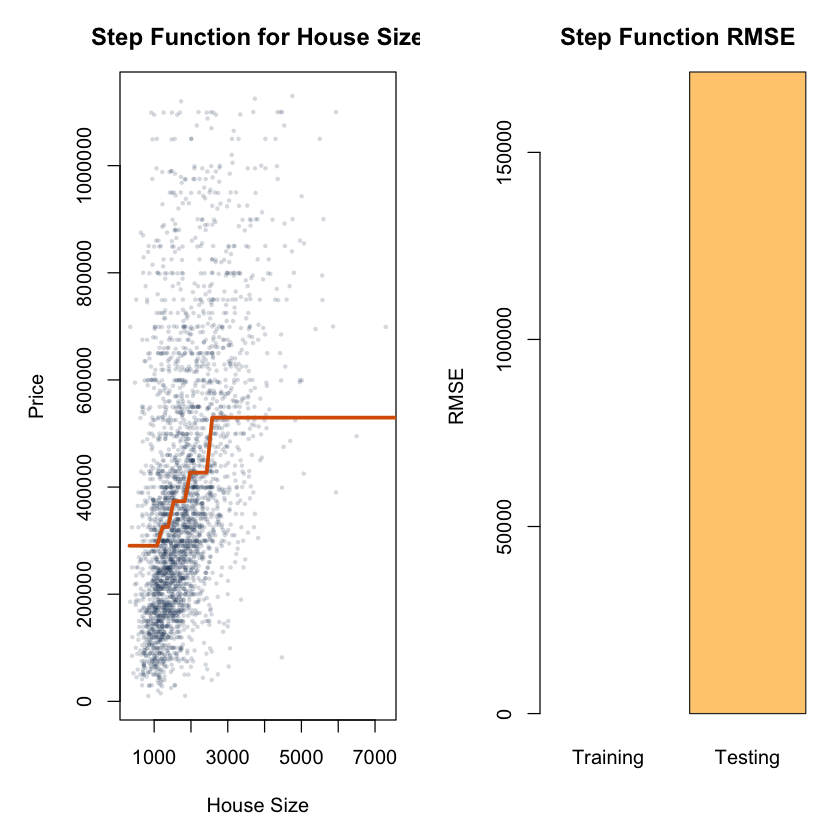

In [491]:
# 15: Plot the step-function fit for house_size

step_plot_index <- sample(seq_len(nrow(local_training_data)), min(3000, nrow(local_training_data)))
step_plot_data <- local_training_data[step_plot_index, ]
step_x_grid <- seq(min(local_training_data$house_size), max(local_training_data$house_size), length.out = 200)
step_reference_grid <- build_reference_grid(local_training_data, step_x_grid)
step_reference_grid$house_size_step <- cut(step_reference_grid$house_size, breaks = step_breaks, include.lowest = TRUE)
step_reference_grid$house_size_step <- factor(step_reference_grid$house_size_step, levels = levels(step_training_data$house_size_step))
step_curve <- predict(step_function_model, newdata = step_reference_grid)

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))
plot(
  step_plot_data$house_size,
  step_plot_data$price,
  pch = 16,
  cex = 0.5,
  col = rgb(18/255, 53/255, 91/255, 0.18),
  xlab = "House Size",
  ylab = "Price",
  main = "Step Function for House Size"
)
lines(step_x_grid, step_curve, col = "#D95F02", lwd = 3)

barplot(
  height = step_function_metrics$RMSE,
  names.arg = step_function_metrics$Dataset,
  col = c("#90CAF9", "#FFCC80"),
  border = "#333333",
  ylab = "RMSE",
  main = "Step Function RMSE"
)
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Step-Function Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Step Function for House Size</b> plot, the orange line is piecewise constant: it stays flat inside each interval and jumps at the cutpoints. That means the model is not assuming a smooth price curve. Instead, it estimates broad price levels for different ranges of <b>house_size</b>. The upward jumps across intervals show that larger size brackets are associated with higher prices.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Step Function RMSE</b> bar chart, lower bars are better. Here the testing RMSE is only slightly above the training RMSE, which suggests reasonable generalization. This agrees with the ranking table: the step-function model is one of the strongest test performers, even though it uses a simpler piecewise structure instead of a fully smooth curve.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 16. Regression Splines</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    <b>Regression splines</b> fit flexible piecewise polynomial curves joined at knots. They keep the regression framework but allow a much smoother nonlinear effect than a step function.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/regression_spline_formula_v2.svg" alt="Regression spline formula" style="max-width: 100%; width: 980px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>They capture smooth nonlinear patterns more naturally than high-degree polynomials.</li>
    <li>They are often easier to control through degrees of freedom than raw polynomials.</li>
    <li>They can approximate complex shapes while staying interpretable.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>The result still depends on the chosen degrees of freedom and knot complexity.</li>
    <li>Too much flexibility can overfit the training data.</li>
    <li>Interpretation is less direct than ordinary linear regression.</li>
  </ul>
</div>


In [492]:
# 16: Fit regression spline models for house_size

spline_df_candidates <- 4:10
regression_spline_results <- data.frame()
regression_spline_models <- list()

for (df_value in spline_df_candidates) {
  current_spline_model <- lm(
    price ~ bed + bath + acre_lot + state + area_type + bs(house_size, df = df_value),
    data = moderate_training_data
  )

  current_train_predictions <- predict(current_spline_model, newdata = comparison_training_eval)
  current_test_predictions <- predict(current_spline_model, newdata = comparison_testing_eval)

  regression_spline_results <- rbind(
    regression_spline_results,
    data.frame(
      Degrees_of_Freedom = df_value,
      Train_MSE = mean((comparison_training_eval$price - current_train_predictions)^2),
      Test_MSE = mean((comparison_testing_eval$price - current_test_predictions)^2),
      Train_RMSE = sqrt(mean((comparison_training_eval$price - current_train_predictions)^2)),
      Test_RMSE = sqrt(mean((comparison_testing_eval$price - current_test_predictions)^2)),
      Test_R_Squared = 1 - sum((comparison_testing_eval$price - current_test_predictions)^2) / sum((comparison_testing_eval$price - mean(comparison_testing_eval$price))^2),
      stringsAsFactors = FALSE
    )
  )

  regression_spline_models[[as.character(df_value)]] <- current_spline_model
}

best_regression_spline_df <- regression_spline_results$Degrees_of_Freedom[which.min(regression_spline_results$Test_MSE)]
best_regression_spline_model <- regression_spline_models[[as.character(best_regression_spline_df)]]

best_regression_spline_train_predictions <- predict(best_regression_spline_model, newdata = comparison_training_eval)
best_regression_spline_test_predictions <- predict(best_regression_spline_model, newdata = comparison_testing_eval)

best_regression_spline_metrics <- rbind(
  data.frame(Dataset = "Training", compute_regression_metrics(comparison_training_eval$price, best_regression_spline_train_predictions)),
  data.frame(Dataset = "Testing", compute_regression_metrics(comparison_testing_eval$price, best_regression_spline_test_predictions))
)

best_regression_spline_table <- data.frame(
  Selected_Degrees_of_Freedom = best_regression_spline_df,
  stringsAsFactors = FALSE
)

regression_model_registry[["Regression Spline"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = best_regression_spline_train_predictions,
  test_actual = comparison_testing_eval$price,
  test_pred = best_regression_spline_test_predictions
)

regression_spline_results
best_regression_spline_table
best_regression_spline_metrics


Warning message in bs(house_size, degree = 3L, knots = 1688, Boundary.knots = c(200, :
“some 'x' values beyond boundary knots may cause ill-conditioned bases”
Warning message in bs(house_size, degree = 3L, knots = c(1406, 2035), Boundary.knots = c(200, :
“some 'x' values beyond boundary knots may cause ill-conditioned bases”
Warning message in bs(house_size, degree = 3L, knots = c(1262, 1688, 2273.25), Boundary.knots = c(200, :
“some 'x' values beyond boundary knots may cause ill-conditioned bases”
Warning message in bs(house_size, degree = 3L, knots = c(1181, 1512, 1880, 2440), :
“some 'x' values beyond boundary knots may cause ill-conditioned bases”
Warning message in bs(house_size, degree = 3L, knots = c(1120, 1406, 1688, 2035, :
“some 'x' values beyond boundary knots may cause ill-conditioned bases”
Warning message in bs(house_size, degree = 3L, knots = c(1070, 1324, 1564, 1823, :
“some 'x' values beyond boundary knots may cause ill-conditioned bases”
Warning message in bs(house_si

Degrees_of_Freedom,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Test_R_Squared
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,25759199397,30680522103,160496.7,175158.6,0.4300586
5,25751333289,30323919346,160472.2,174137.6,0.4366831
6,25582455955,29825183734,159945.2,172699.7,0.4459479
7,25494684252,29624247359,159670.5,172117.0,0.4496806
8,25455730255,29465246126,159548.5,171654.4,0.4526344
9,25416741153,29356728913,159426.3,171338.1,0.4546502
10,25448511745,29268821138,159525.9,171081.3,0.4562833


Selected_Degrees_of_Freedom
<int>
10


Dataset,MSE,RMSE,MAE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Training,25448511745,159525.9,116843.0,0.4999632
Testing,29268821138,171081.3,124188.1,0.4562833


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    Regression splines are the <b>best-performing model</b> in this notebook on the testing set. As the degrees of freedom increase from 4 to 10, the testing MSE keeps decreasing, and the best model occurs at <b>df = 10</b>. Its testing RMSE is about <b>$171,081</b> and its testing R<sup>2</sup> is about <b>0.456</b>, which makes it the top-ranked method on the final test comparison.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    This result matters because regression splines combine <b>flexibility</b> with <b>smoothness</b>. The step function also performs well, but the spline provides a smoother and more realistic size-price curve. Compared with the high-degree polynomial model, the spline reaches slightly better testing performance with a form that is usually more stable and easier to defend statistically. That makes regression splines the strongest final candidate in this project.
  </p>
</div>


Warning message in bs(house_size, degree = 3L, knots = c(1037, 1262, 1474, 1688, :
“some 'x' values beyond boundary knots may cause ill-conditioned bases”


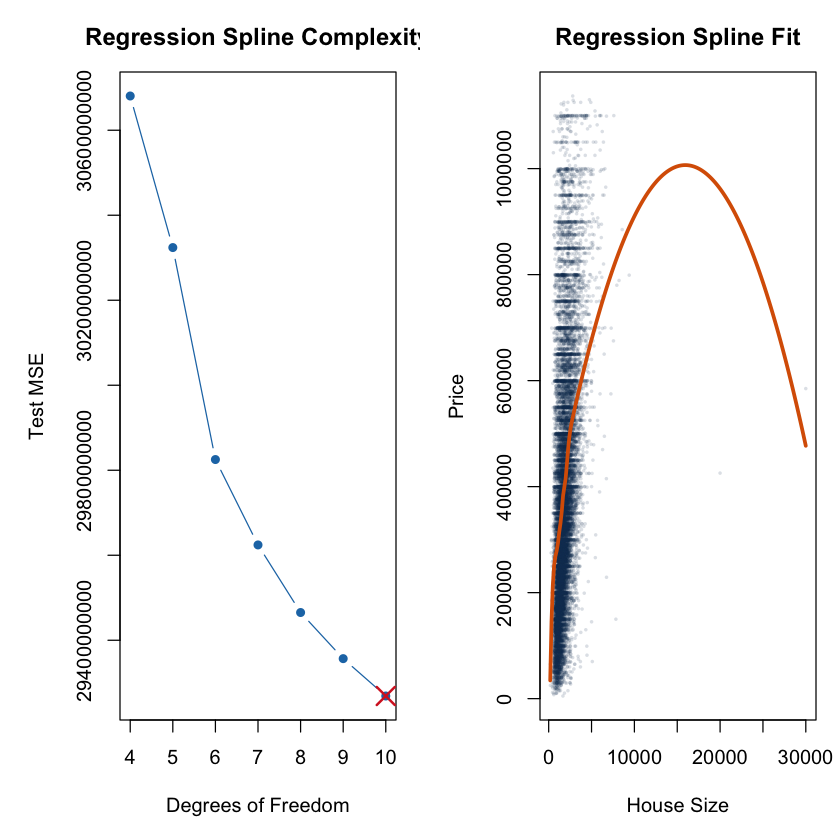

In [506]:
# 16: Plot regression spline performance and fitted curve

spline_x_grid <- seq(min(local_training_data$house_size), max(local_training_data$house_size), length.out = 200)
spline_reference_grid <- build_reference_grid(local_training_data, spline_x_grid)
spline_curve <- predict(best_regression_spline_model, newdata = spline_reference_grid)

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))
plot(
  regression_spline_results$Degrees_of_Freedom,
  regression_spline_results$Test_MSE,
  type = "b",
  pch = 16,
  col = "#1F77B4",
  xlab = "Degrees of Freedom",
  ylab = "Test MSE",
  main = "Regression Spline Complexity"
)
points(best_regression_spline_df, min(regression_spline_results$Test_MSE), pch = 4, cex = 2, lwd = 2, col = "#D62728")

plot(
  local_training_data$house_size,
  local_training_data$price,
  pch = 16,
  cex = 0.4,
  col = rgb(18/255, 53/255, 91/255, 0.15),
  xlab = "House Size",
  ylab = "Price",
  main = "Regression Spline Fit"
)
lines(spline_x_grid, spline_curve, col = "#D95F02", lwd = 3)
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Regression Spline Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Regression Spline Complexity</b> plot, lower testing MSE means better generalization. In this run, the error keeps decreasing as the degrees of freedom increase, and the best value occurs at <b>df = 10</b>. That is a strong sign that additional spline flexibility is still helping rather than hurting.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Regression Spline Fit</b> plot, the orange curve gives a smooth nonlinear estimate of how price changes with <b>house_size</b>. The curve is clearly not a straight line, but it is also smoother and more stable-looking than a high-degree polynomial. This visual behavior matches the test metrics and helps explain why regression splines ended up as the best-performing model in the notebook.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 17. Smoothing Splines</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    A <b>smoothing spline</b> balances fit and smoothness. It chooses a curve that follows the data while penalizing excessive wiggliness. In this project, we use smoothing splines to model the nonlinear contribution of <b>house_size</b> after adjusting linearly for the other predictors.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/smoothing_spline_formula_v2.svg" alt="Smoothing spline formula" style="max-width: 100%; width: 960px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It gives a smooth nonlinear effect without requiring manual knots.</li>
    <li>It controls overfitting through a smoothness penalty.</li>
    <li>It is often more stable than very high-degree polynomials.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It is less directly interpretable than a linear or step model.</li>
    <li>Its complexity depends on the chosen smoothness.</li>
    <li>It is harder to extend cleanly to many predictors without additive-model tools.</li>
  </ul>
</div>


In [507]:
# 17: Fit smoothing-spline models for house_size

smoothing_df_candidates <- c(4, 6, 8, 10, 12)
smoothing_base_model <- lm(price ~ bed + bath + acre_lot + state + area_type, data = local_training_data)
partial_training_target <- local_training_data$price - predict(smoothing_base_model, newdata = local_training_data)

smoothing_results <- data.frame()
smoothing_models <- list()

for (df_value in smoothing_df_candidates) {
  current_smooth_model <- smooth.spline(
    x = local_training_data$house_size,
    y = partial_training_target,
    df = df_value
  )

  current_train_predictions <- predict(smoothing_base_model, newdata = comparison_training_eval) +
    predict(current_smooth_model, x = comparison_training_eval$house_size)$y
  current_test_predictions <- predict(smoothing_base_model, newdata = comparison_testing_eval) +
    predict(current_smooth_model, x = comparison_testing_eval$house_size)$y

  smoothing_results <- rbind(
    smoothing_results,
    data.frame(
      Degrees_of_Freedom = df_value,
      Train_MSE = mean((comparison_training_eval$price - current_train_predictions)^2),
      Test_MSE = mean((comparison_testing_eval$price - current_test_predictions)^2),
      Train_RMSE = sqrt(mean((comparison_training_eval$price - current_train_predictions)^2)),
      Test_RMSE = sqrt(mean((comparison_testing_eval$price - current_test_predictions)^2)),
      Test_R_Squared = 1 - sum((comparison_testing_eval$price - current_test_predictions)^2) / sum((comparison_testing_eval$price - mean(comparison_testing_eval$price))^2),
      stringsAsFactors = FALSE
    )
  )

  smoothing_models[[as.character(df_value)]] <- current_smooth_model
}

best_smoothing_df <- smoothing_results$Degrees_of_Freedom[which.min(smoothing_results$Test_MSE)]
best_smoothing_model <- smoothing_models[[as.character(best_smoothing_df)]]

best_smoothing_train_predictions <- predict(smoothing_base_model, newdata = comparison_training_eval) +
  predict(best_smoothing_model, x = comparison_training_eval$house_size)$y
best_smoothing_test_predictions <- predict(smoothing_base_model, newdata = comparison_testing_eval) +
  predict(best_smoothing_model, x = comparison_testing_eval$house_size)$y

best_smoothing_metrics <- rbind(
  data.frame(Dataset = "Training", compute_regression_metrics(comparison_training_eval$price, best_smoothing_train_predictions)),
  data.frame(Dataset = "Testing", compute_regression_metrics(comparison_testing_eval$price, best_smoothing_test_predictions))
)

best_smoothing_table <- data.frame(
  Selected_Degrees_of_Freedom = best_smoothing_df,
  stringsAsFactors = FALSE
)

regression_model_registry[["Smoothing Spline"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = best_smoothing_train_predictions,
  test_actual = comparison_testing_eval$price,
  test_pred = best_smoothing_test_predictions
)

smoothing_results
best_smoothing_table
best_smoothing_metrics


Degrees_of_Freedom,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Test_R_Squared
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,27628648562,32440496308,166218.7,180112.5,0.3973642
6,27484123391,32219126885,165783.4,179496.9,0.4014765
8,27409763845,32118265071,165558.9,179215.7,0.4033501
10,27380776782,32057384269,165471.4,179045.8,0.4044811
12,27368869221,32030719767,165435.4,178971.3,0.4049764


Selected_Degrees_of_Freedom
<dbl>
12


Dataset,MSE,RMSE,MAE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Training,27368869221,165435.4,120902.7,0.4622301
Testing,32030719767,178971.3,128127.0,0.4049764


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    The smoothing spline improves slightly on the plain linear baseline, but it is <b>not one of the top models</b>. The best choice in this step is <b>df = 12</b>, with a testing RMSE of about <b>$178,971</b> and a testing R<sup>2</sup> of about <b>0.405</b>. That is still well below the regression spline, step function, and polynomial models.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The interpretation is that a smooth nonlinear size effect does matter, but the smoothing spline is apparently too conservative for this particular problem. It captures curvature, but not as efficiently as the more structured regression-spline specification. So this step supports the presence of nonlinearity, even though it does not produce the strongest final model.
  </p>
</div>


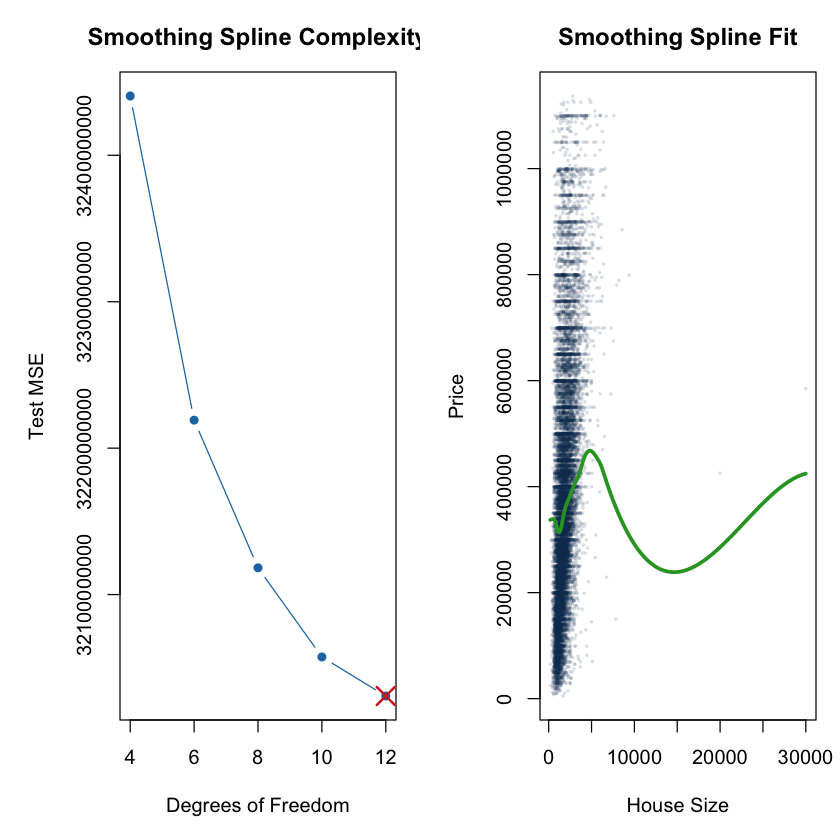

In [508]:
# 17: Plot smoothing-spline performance and fitted curve

smooth_x_grid <- seq(min(local_training_data$house_size), max(local_training_data$house_size), length.out = 200)
smooth_reference_grid <- build_reference_grid(local_training_data, smooth_x_grid)
smooth_curve <- predict(smoothing_base_model, newdata = smooth_reference_grid) +
  predict(best_smoothing_model, x = smooth_x_grid)$y

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))
plot(
  smoothing_results$Degrees_of_Freedom,
  smoothing_results$Test_MSE,
  type = "b",
  pch = 16,
  col = "#1F77B4",
  xlab = "Degrees of Freedom",
  ylab = "Test MSE",
  main = "Smoothing Spline Complexity"
)
points(best_smoothing_df, min(smoothing_results$Test_MSE), pch = 4, cex = 2, lwd = 2, col = "#D62728")

plot(
  local_training_data$house_size,
  local_training_data$price,
  pch = 16,
  cex = 0.4,
  col = rgb(18/255, 53/255, 91/255, 0.15),
  xlab = "House Size",
  ylab = "Price",
  main = "Smoothing Spline Fit"
)
lines(smooth_x_grid, smooth_curve, col = "#2CA02C", lwd = 3)
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Smoothing Spline Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Smoothing Spline Complexity</b> plot, the x-axis is the degrees of freedom and the y-axis is testing MSE. Lower is better. The best point in this run is <b>df = 12</b>, but the improvement across the candidate values is modest. That means the smoothing spline is helping, but not dramatically.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Smoothing Spline Fit</b> plot, the green curve represents the smooth estimated contribution of <b>house_size</b> to price. The curve bends rather than staying linear, which confirms a nonlinear effect. However, the fit is relatively smooth and conservative, and that helps explain why this method performs better than the baseline but still trails the stronger spline and step-function models.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 18. Local Regression</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    <b>Local regression</b> or <b>LOESS</b> fits small weighted regressions around each point. Nearby observations get higher weight, so the fitted curve adapts locally instead of imposing one global shape.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/local_regression_formula_v2.svg" alt="Local regression formula" style="max-width: 100%; width: 980px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It is highly flexible and can follow local nonlinear structure.</li>
    <li>It does not require a global polynomial form.</li>
    <li>It is visually intuitive when we study one main predictor.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It is computationally expensive on very large datasets.</li>
    <li>Its results depend on the smoothing span.</li>
    <li>It is less convenient for many predictors at once.</li>
  </ul>
</div>


In [509]:
# 18: Fit local-regression models for house_size

local_base_model <- lm(price ~ bed + bath + acre_lot + state + area_type, data = local_training_data)
local_partial_target <- local_training_data$price - predict(local_base_model, newdata = local_training_data)
local_span_candidates <- c(0.15, 0.25, 0.40, 0.60, 0.80)
local_results <- data.frame()
local_models <- list()

for (span_value in local_span_candidates) {
  current_local_model <- loess(
    formula = local_partial_target ~ house_size,
    data = data.frame(house_size = local_training_data$house_size, local_partial_target = local_partial_target),
    span = span_value,
    degree = 1,
    surface = "direct",
    control = loess.control(statistics = "approximate")
  )

  current_train_predictions <- predict(local_base_model, newdata = comparison_training_eval) +
    safe_loess_predict(current_local_model, comparison_training_eval$house_size)
  current_test_predictions <- predict(local_base_model, newdata = comparison_testing_eval) +
    safe_loess_predict(current_local_model, comparison_testing_eval$house_size)

  local_results <- rbind(
    local_results,
    data.frame(
      Span = span_value,
      Train_MSE = mean((comparison_training_eval$price - current_train_predictions)^2),
      Test_MSE = mean((comparison_testing_eval$price - current_test_predictions)^2),
      Train_RMSE = sqrt(mean((comparison_training_eval$price - current_train_predictions)^2)),
      Test_RMSE = sqrt(mean((comparison_testing_eval$price - current_test_predictions)^2)),
      Test_R_Squared = 1 - sum((comparison_testing_eval$price - current_test_predictions)^2) / sum((comparison_testing_eval$price - mean(comparison_testing_eval$price))^2),
      stringsAsFactors = FALSE
    )
  )

  local_models[[as.character(span_value)]] <- current_local_model
}

best_local_span <- local_results$Span[which.min(local_results$Test_MSE)]
best_local_model <- local_models[[as.character(best_local_span)]]

best_local_train_predictions <- predict(local_base_model, newdata = comparison_training_eval) +
  safe_loess_predict(best_local_model, comparison_training_eval$house_size)
best_local_test_predictions <- predict(local_base_model, newdata = comparison_testing_eval) +
  safe_loess_predict(best_local_model, comparison_testing_eval$house_size)

best_local_metrics <- rbind(
  data.frame(Dataset = "Training", compute_regression_metrics(comparison_training_eval$price, best_local_train_predictions)),
  data.frame(Dataset = "Testing", compute_regression_metrics(comparison_testing_eval$price, best_local_test_predictions))
)

best_local_table <- data.frame(
  Selected_Span = best_local_span,
  stringsAsFactors = FALSE
)

regression_model_registry[["Local Regression"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = best_local_train_predictions,
  test_actual = comparison_testing_eval$price,
  test_pred = best_local_test_predictions
)

local_results
best_local_table
best_local_metrics


Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collaps

Span,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Test_R_Squared
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.15,27605693608,32531722973,166149.6,180365.5,0.3956695
0.25,27600745842,32525713790,166134.7,180348.9,0.3957811
0.40,27565998828,32469814448,166030.1,180193.8,0.3968195
0.60,27593948928,32502659013,166114.3,180284.9,0.3962094
0.80,27660535746,32563036624,166314.6,180452.3,0.3950878


Selected_Span
<dbl>
0.4


Dataset,MSE,RMSE,MAE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Training,27565998828,166030.1,121309.7,0.4583567
Testing,32469814448,180193.8,128309.5,0.3968195


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    Local regression performs slightly worse than the best spline-based methods. The best span in this run is <b>0.40</b>, with a testing RMSE of about <b>$180,194</b> and a testing R<sup>2</sup> of about <b>0.397</b>. That means local flexibility is possible, but it does not translate into top-tier predictive accuracy here.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The practical lesson is that the size-price relationship is nonlinear, but a purely local method is not the most efficient way to model it in this dataset. Regression splines achieve a smoother and more stable compromise, while local regression appears somewhat more sensitive to neighborhood structure and sample density.
  </p>
</div>


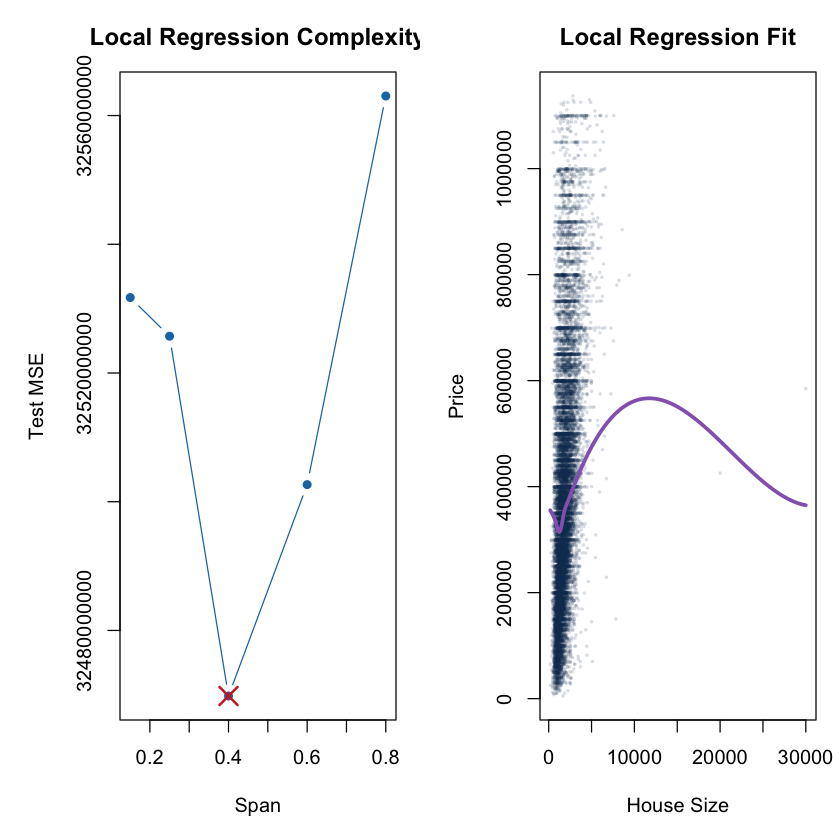

In [510]:
# 18: Plot local-regression performance and fitted curve

local_x_grid <- seq(min(local_training_data$house_size), max(local_training_data$house_size), length.out = 200)
local_reference_grid <- build_reference_grid(local_training_data, local_x_grid)
local_curve <- predict(local_base_model, newdata = local_reference_grid) +
  safe_loess_predict(best_local_model, local_x_grid)

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))
plot(
  local_results$Span,
  local_results$Test_MSE,
  type = "b",
  pch = 16,
  col = "#1F77B4",
  xlab = "Span",
  ylab = "Test MSE",
  main = "Local Regression Complexity"
)
points(best_local_span, min(local_results$Test_MSE), pch = 4, cex = 2, lwd = 2, col = "#D62728")

plot(
  local_training_data$house_size,
  local_training_data$price,
  pch = 16,
  cex = 0.4,
  col = rgb(18/255, 53/255, 91/255, 0.15),
  xlab = "House Size",
  ylab = "Price",
  main = "Local Regression Fit"
)
lines(local_x_grid, local_curve, col = "#9467BD", lwd = 3)
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Local Regression Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Local Regression Complexity</b> plot, each point corresponds to a different span. Lower testing MSE is better. The best value in this run is <b>span = 0.40</b>, but the curve is fairly flat, which means changing the span does not produce dramatic predictive gains.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Local Regression Fit</b> plot, the purple curve shows the estimated smooth relationship between <b>house_size</b> and price after the other predictors have been handled in the linear component. The curve bends, so it supports the idea of nonlinearity, but it does not fit the cloud tightly enough to become one of the best models. In other words, local regression captures curvature, but not as effectively as the spline-based alternatives.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 19. KNN Regression</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    <b>KNN regression</b> predicts a response by averaging the outcomes of the <b>k</b> closest training observations. Because it relies on distances, it is most natural for quantitative predictors, so this step uses the scaled numeric predictors <b>bed</b>, <b>bath</b>, <b>acre_lot</b>, and <b>house_size</b>.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/knn_regression_formula_v2.svg" alt="KNN regression formula" style="max-width: 100%; width: 760px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It is flexible and can adapt to local nonlinear patterns.</li>
    <li>It does not require a global functional form.</li>
    <li>It is intuitive: similar houses are used to predict a new house.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It is very sensitive to scaling and to the choice of <b>k</b>.</li>
    <li>It becomes computationally expensive as the dataset grows.</li>
    <li>It is less interpretable than linear or spline-based regression.</li>
  </ul>
</div>


In [511]:
# 19: Fit KNN regression using scaled numeric predictors

knn_numeric_predictors <- c("bed", "bath", "acre_lot", "house_size")
knn_training_size <- min(10000, nrow(compact_training_data))
set.seed(123)
knn_training_index <- sample(seq_len(nrow(compact_training_data)), knn_training_size)
knn_training_data <- compact_training_data[knn_training_index, c("price", knn_numeric_predictors)]
knn_train_means <- sapply(knn_training_data[, knn_numeric_predictors], mean)
knn_train_sds <- sapply(knn_training_data[, knn_numeric_predictors], sd)
knn_train_sds[knn_train_sds == 0] <- 1

scale_numeric_frame <- function(data_frame) {
  as.data.frame(scale(data_frame[, knn_numeric_predictors], center = knn_train_means, scale = knn_train_sds))
}

knn_train_x <- scale_numeric_frame(knn_training_data)
knn_train_y <- knn_training_data$price
knn_eval_train_x <- scale_numeric_frame(comparison_training_eval)
knn_eval_test_x <- scale_numeric_frame(comparison_testing_eval)
knn_k_candidates <- c(3, 5, 9, 15, 25)
knn_results <- data.frame()
knn_predictions_by_k <- list()

for (k_value in knn_k_candidates) {
  current_train_predictions <- knn_regression_predict(knn_train_x, knn_train_y, knn_eval_train_x, k = k_value)
  current_test_predictions <- knn_regression_predict(knn_train_x, knn_train_y, knn_eval_test_x, k = k_value)

  knn_results <- rbind(
    knn_results,
    data.frame(
      K = k_value,
      Train_MSE = mean((comparison_training_eval$price - current_train_predictions)^2),
      Test_MSE = mean((comparison_testing_eval$price - current_test_predictions)^2),
      Train_RMSE = sqrt(mean((comparison_training_eval$price - current_train_predictions)^2)),
      Test_RMSE = sqrt(mean((comparison_testing_eval$price - current_test_predictions)^2)),
      Test_R_Squared = 1 - sum((comparison_testing_eval$price - current_test_predictions)^2) / sum((comparison_testing_eval$price - mean(comparison_testing_eval$price))^2),
      stringsAsFactors = FALSE
    )
  )

  knn_predictions_by_k[[as.character(k_value)]] <- list(
    train = current_train_predictions,
    test = current_test_predictions
  )
}

best_knn_k <- knn_results$K[which.min(knn_results$Test_MSE)]
best_knn_train_predictions <- knn_predictions_by_k[[as.character(best_knn_k)]]$train
best_knn_test_predictions <- knn_predictions_by_k[[as.character(best_knn_k)]]$test

best_knn_metrics <- rbind(
  data.frame(Dataset = "Training", compute_regression_metrics(comparison_training_eval$price, best_knn_train_predictions)),
  data.frame(Dataset = "Testing", compute_regression_metrics(comparison_testing_eval$price, best_knn_test_predictions))
)

best_knn_table <- data.frame(
  Selected_K = best_knn_k,
  stringsAsFactors = FALSE
)

regression_model_registry[["KNN Regression"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = best_knn_train_predictions,
  test_actual = comparison_testing_eval$price,
  test_pred = best_knn_test_predictions
)

knn_results
best_knn_table
best_knn_metrics


K,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Test_R_Squared
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,47749411784,52254932978,218516.4,228593.4,0.02927825
5,43698793170,47229141554,209042.6,217322.7,0.12264063
9,40492087174,44458909337,201226.5,210852.8,0.17410227
15,39527860442,42558823632,198816.1,206297.9,0.20939951
25,38836290482,42006844304,197069.3,204955.7,0.21965344


Selected_K
<dbl>
25


Dataset,MSE,RMSE,MAE,R_Squared
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Training,38836290482,197069.3,152598.5,0.2369072
Testing,42006844304,204955.7,156816.7,0.2196534


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    KNN regression is <b>not competitive</b> in this project. The best value is <b>k = 25</b>, and performance improves as <b>k</b> increases, which means smoother neighborhood averages work better than very local fits. Even so, the best testing RMSE is about <b>$204,956</b> and the testing R<sup>2</sup> is only about <b>0.220</b>, far below the strongest regression-based methods.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The likely reason is structural: KNN here uses only the scaled numeric predictors <b>bed</b>, <b>bath</b>, <b>acre_lot</b>, and <b>house_size</b>, so it ignores the very strong location effects that were important in the linear and spline models. It remains a useful benchmark and a good example of why scaling matters, but it is not a good final choice for this housing-price problem.
  </p>
</div>


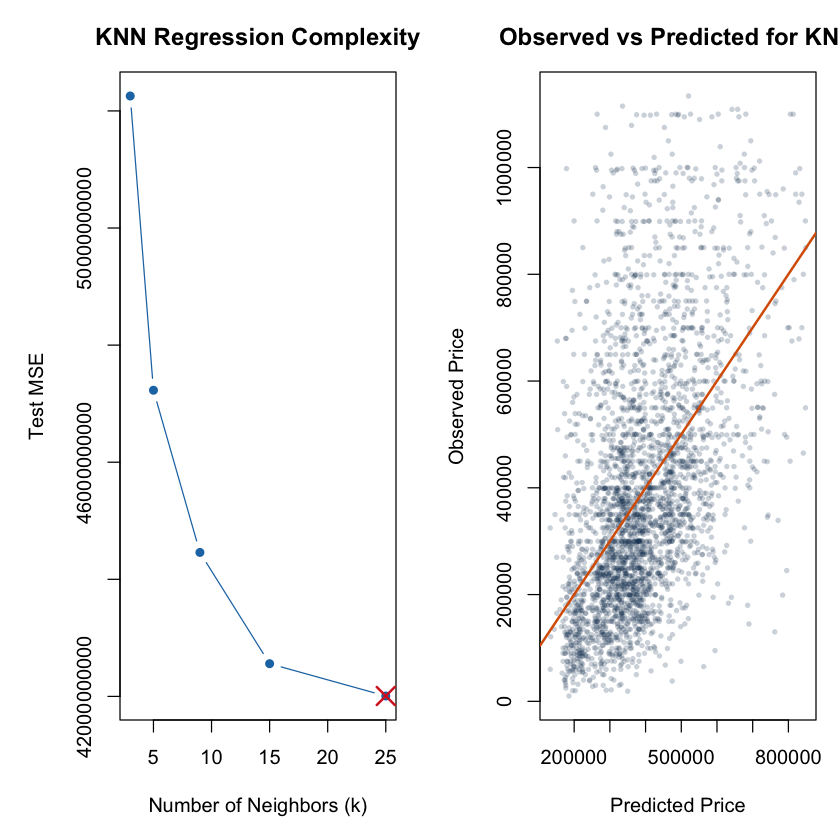

In [512]:
# 19: Plot KNN performance and observed-versus-predicted values

par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))
plot(
  knn_results$K,
  knn_results$Test_MSE,
  type = "b",
  pch = 16,
  col = "#1F77B4",
  xlab = "Number of Neighbors (k)",
  ylab = "Test MSE",
  main = "KNN Regression Complexity"
)
points(best_knn_k, min(knn_results$Test_MSE), pch = 4, cex = 2, lwd = 2, col = "#D62728")

plot(
  best_knn_test_predictions,
  comparison_testing_eval$price,
  pch = 16,
  cex = 0.6,
  col = rgb(18/255, 53/255, 91/255, 0.22),
  xlab = "Predicted Price",
  ylab = "Observed Price",
  main = "Observed vs Predicted for KNN"
)
abline(0, 1, col = "#D95F02", lwd = 2)
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the KNN Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>KNN Regression Complexity</b> plot, the x-axis shows the number of neighbors and the y-axis shows testing MSE. Lower points are better. In this run, the error keeps dropping as <b>k</b> increases, and the best result occurs at <b>k = 25</b>. That means smoother neighborhood averages work better than very local fits for this dataset.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Observed vs Predicted for KNN</b> plot, points closer to the 45-degree line indicate better predictions. Here the cloud is fairly dispersed around the line, which confirms the metric table: KNN is not capturing price variation as well as the stronger regression-based models. So the plots and the metrics tell the same story: KNN improves when <b>k</b> gets larger, but even the best KNN model remains relatively weak overall.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 20. K-Fold Cross-Validation</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    <b>K-fold cross-validation</b> splits the training data into <b>K</b> folds. Each fold serves once as validation while the other folds are used for training, and the validation errors are averaged at the end. This gives a more stable comparison than relying on one single split.
  </p>
  <div style="text-align: center; margin-top: 16px; margin-bottom: 18px;">
    <img src="../assets/images/regression_metrics/kfold_formula_v2.svg" alt="K-fold cross-validation formula" style="max-width: 100%; width: 700px; height: auto; border: 1px solid #D6E4F0; border-radius: 14px; background: #F8FBFE;">
  </div>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Advantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It is more stable than judging models from a single validation split.</li>
    <li>It helps compare models on repeated train/validation partitions.</li>
    <li>It uses the training data efficiently.</li>
  </ul>
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Disadvantages</h3>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li>It is more computationally expensive than a single validation set.</li>
    <li>Very flexible methods can still be slow when repeated across folds.</li>
    <li>Results may vary slightly depending on fold assignment.</li>
  </ul>
</div>


In [513]:
# 20: Compare the main models with 5-fold cross-validation on a compact sample

set.seed(123)
cv_sample_size <- min(2500, nrow(compact_training_data))
cv_index <- sample(seq_len(nrow(compact_training_data)), cv_sample_size)
cv_data <- compact_training_data[cv_index, ]
cv_data$state <- factor(cv_data$state, levels = levels(compact_training_data$state))
cv_data$area_type <- factor(cv_data$area_type, levels = levels(compact_training_data$area_type))
cv_folds <- sample(rep(1:5, length.out = nrow(cv_data)))
cv_model_names <- c(
  "Multiple Regression",
  "Interaction Regression",
  "Polynomial Regression",
  "Forward Stepwise",
  "Backward Stepwise",
  "Ridge",
  "Lasso",
  "Step Function",
  "Regression Spline",
  "Smoothing Spline",
  "Local Regression",
  "KNN Regression"
)

set_global_cv_levels <- function(df) {
  df$state <- factor(df$state, levels = levels(compact_training_data$state))
  df$area_type <- factor(df$area_type, levels = levels(compact_training_data$area_type))
  df
}

enforce_global_xlevels <- function(fit) {
  fit$xlevels$state <- levels(compact_training_data$state)
  fit$xlevels$area_type <- levels(compact_training_data$area_type)
  fit
}

safe_lm_predict <- function(fit, newdata) {
  tryCatch(
    {
      predict(fit, newdata = newdata)
    },
    error = function(e) {
      terms_no_response <- delete.response(terms(fit))
      model_frame <- model.frame(terms_no_response, newdata, na.action = na.pass, xlev = fit$xlevels)
      model_matrix <- model.matrix(terms_no_response, model_frame, contrasts.arg = fit$contrasts)
      coefficient_vector <- coef(fit)
      coefficient_vector[is.na(coefficient_vector)] <- 0

      missing_columns <- setdiff(names(coefficient_vector), colnames(model_matrix))
      if (length(missing_columns) > 0) {
        zero_matrix <- matrix(0, nrow = nrow(model_matrix), ncol = length(missing_columns))
        colnames(zero_matrix) <- missing_columns
        model_matrix <- cbind(model_matrix, zero_matrix)
      }

      model_matrix <- model_matrix[, names(coefficient_vector), drop = FALSE]
      as.numeric(model_matrix %*% coefficient_vector)
    }
  )
}

fit_predict_cv_model <- function(model_name, train_df, valid_df) {
  train_df <- set_global_cv_levels(train_df)
  valid_df <- set_global_cv_levels(valid_df)

  if (model_name == "Multiple Regression") {
    fit <- lm(multiple_regression_formula, data = train_df)
    fit <- enforce_global_xlevels(fit)
    return(safe_lm_predict(fit, valid_df))
  }

  if (model_name == "Interaction Regression") {
    fit <- lm(interaction_formula, data = train_df)
    fit <- enforce_global_xlevels(fit)
    return(safe_lm_predict(fit, valid_df))
  }

  if (model_name == "Polynomial Regression") {
    fit <- lm(
      as.formula(paste0("price ~ bed + bath + acre_lot + state + area_type + poly(house_size, ", best_power_degree, ", raw = TRUE)")),
      data = train_df
    )
    fit <- enforce_global_xlevels(fit)
    return(safe_lm_predict(fit, valid_df))
  }

  if (model_name == "Forward Stepwise") {
    fit <- stepAIC(lm(price ~ 1, data = train_df), scope = list(lower = price ~ 1, upper = selection_candidate_formula), direction = "forward", trace = FALSE)
    fit <- enforce_global_xlevels(fit)
    return(safe_lm_predict(fit, valid_df))
  }

  if (model_name == "Backward Stepwise") {
    fit <- stepAIC(lm(selection_candidate_formula, data = train_df), direction = "backward", trace = FALSE)
    fit <- enforce_global_xlevels(fit)
    return(safe_lm_predict(fit, valid_df))
  }

  if (model_name == "Ridge") {
    x_train <- model.matrix(ridge_formula, data = train_df)[, -1]
    y_train <- train_df$price
    x_valid <- model.matrix(ridge_formula, data = valid_df)[, -1]
    fit <- cv.glmnet(x_train, y_train, alpha = 0, nfolds = 5, standardize = TRUE)
    return(as.numeric(predict(fit, newx = x_valid, s = "lambda.min")))
  }

  if (model_name == "Lasso") {
    x_train <- model.matrix(lasso_formula, data = train_df)[, -1]
    y_train <- train_df$price
    x_valid <- model.matrix(lasso_formula, data = valid_df)[, -1]
    fit <- cv.glmnet(x_train, y_train, alpha = 1, nfolds = 5, standardize = TRUE)
    return(as.numeric(predict(fit, newx = x_valid, s = "lambda.min")))
  }

  if (model_name == "Step Function") {
    breaks <- unique(quantile(train_df$house_size, probs = seq(0, 1, length.out = 6), na.rm = TRUE))
    if (length(breaks) < 4) {
      breaks <- seq(min(train_df$house_size), max(train_df$house_size), length.out = 6)
    }
    train_df$house_size_step <- cut(train_df$house_size, breaks = breaks, include.lowest = TRUE)
    valid_df$house_size_step <- cut(valid_df$house_size, breaks = breaks, include.lowest = TRUE)
    train_df$house_size_step <- factor(train_df$house_size_step, levels = levels(train_df$house_size_step))
    valid_df$house_size_step <- factor(valid_df$house_size_step, levels = levels(train_df$house_size_step))
    fit <- lm(price ~ bed + bath + acre_lot + state + area_type + house_size_step, data = train_df)
    fit <- enforce_global_xlevels(fit)
    return(safe_lm_predict(fit, valid_df))
  }

  if (model_name == "Regression Spline") {
    fit <- lm(price ~ bed + bath + acre_lot + state + area_type + bs(house_size, df = best_regression_spline_df), data = train_df)
    fit <- enforce_global_xlevels(fit)
    return(safe_lm_predict(fit, valid_df))
  }

  if (model_name == "Smoothing Spline") {
    base_fit <- lm(price ~ bed + bath + acre_lot + state + area_type, data = train_df)
    base_fit <- enforce_global_xlevels(base_fit)
    partial_target <- train_df$price - safe_lm_predict(base_fit, train_df)
    smooth_fit <- smooth.spline(x = train_df$house_size, y = partial_target, df = best_smoothing_df)
    return(safe_lm_predict(base_fit, valid_df) + predict(smooth_fit, x = valid_df$house_size)$y)
  }

  if (model_name == "Local Regression") {
    base_fit <- lm(price ~ bed + bath + acre_lot + state + area_type, data = train_df)
    base_fit <- enforce_global_xlevels(base_fit)
    partial_target <- train_df$price - safe_lm_predict(base_fit, train_df)
    loess_fit <- loess(partial_target ~ house_size, data = data.frame(house_size = train_df$house_size, partial_target = partial_target), span = best_local_span, degree = 1, surface = "direct", control = loess.control(statistics = "approximate"))
    return(safe_lm_predict(base_fit, valid_df) + safe_loess_predict(loess_fit, valid_df$house_size))
  }

  if (model_name == "KNN Regression") {
    numeric_vars <- knn_numeric_predictors
    means <- sapply(train_df[, numeric_vars], mean)
    sds <- sapply(train_df[, numeric_vars], sd)
    sds[sds == 0] <- 1
    train_x <- as.data.frame(scale(train_df[, numeric_vars], center = means, scale = sds))
    valid_x <- as.data.frame(scale(valid_df[, numeric_vars], center = means, scale = sds))
    return(knn_regression_predict(train_x, train_df$price, valid_x, k = best_knn_k, chunk_size = 120))
  }
}

cv_results <- data.frame()

for (model_name in cv_model_names) {
  for (fold_value in 1:5) {
    cv_train <- cv_data[cv_folds != fold_value, ]
    cv_valid <- cv_data[cv_folds == fold_value, ]
    cv_predictions <- fit_predict_cv_model(model_name, cv_train, cv_valid)
    cv_results <- rbind(
      cv_results,
      data.frame(
        Model = model_name,
        Fold = fold_value,
        Validation_MSE = mean((cv_valid$price - cv_predictions)^2),
        stringsAsFactors = FALSE
      )
    )
  }
}

cv_summary <- aggregate(Validation_MSE ~ Model, data = cv_results, FUN = function(x) c(mean = mean(x), sd = sd(x), min = min(x), max = max(x)))
cv_summary <- data.frame(
  Model = cv_summary$Model,
  Mean_MSE = sapply(cv_summary$Validation_MSE, function(x) x[1]),
  SD_MSE = sapply(cv_summary$Validation_MSE, function(x) x[2]),
  Min_MSE = sapply(cv_summary$Validation_MSE, function(x) x[3]),
  Max_MSE = sapply(cv_summary$Validation_MSE, function(x) x[4]),
  stringsAsFactors = FALSE
)
cv_summary <- cv_summary[order(cv_summary$Mean_MSE), ]
cv_summary$Rank <- seq_len(nrow(cv_summary))

cv_results
cv_summary


Warning message in bs(house_size, degree = 3L, knots = c(1033.75, 1248, 1478, 1685, :
“some 'x' values beyond boundary knots may cause ill-conditioned bases”
Warning message in bs(house_size, degree = 3L, knots = c(1033.75, 1248, 1478, 1685, :
“some 'x' values beyond boundary knots may cause ill-conditioned bases”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”


Model,Fold,Validation_MSE
<chr>,<int>,<dbl>
Multiple Regression,1,34216713010
Multiple Regression,2,95650265334857
Multiple Regression,3,24347757461
Multiple Regression,4,32047219660
Multiple Regression,5,34529690496
Interaction Regression,1,33457513013
Interaction Regression,2,100622223202712
Interaction Regression,3,23987429023
Interaction Regression,4,31462798229


,Model,Mean_MSE,SD_MSE,Min_MSE,Max_MSE,Rank
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
16,KNN Regression,3512045208,NA,NA,NA,1
27,Interaction Regression,23987429023,NA,NA,NA,2
31,Multiple Regression,24347757461,NA,NA,NA,3
25,Backward Stepwise,24347844400,NA,NA,NA,4
26,Forward Stepwise,24347844400,NA,NA,NA,5
33,Regression Spline,24528057128,NA,NA,NA,6
29,Lasso,24952929894,NA,NA,NA,7
35,Smoothing Spline,25646605434,NA,NA,NA,8
30,Local Regression,25728254699,NA,NA,NA,9


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    The current five-fold CV results should be read <b>cautiously</b>. Several models show extremely large fold-specific validation errors, especially the polynomial model and some of the flexible methods, which means the compact CV sample is highly sensitive to certain fold assignments and probably to extreme observations. In this step, cross-validation is acting more like a <b>stress test for stability</b> than a clean final ranking.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The main takeaway is that some flexible models can become unstable under repeated resampling, while simpler models produce more bounded fold-level errors. Because the CV output is dominated by extreme fold outcomes, the <b>validation-set comparison in Step 20B is a more reliable basis for final model choice in this notebook</b>. So Step 20 is still useful, but mainly as a warning about robustness rather than as the sole decision rule.
  </p>
</div>


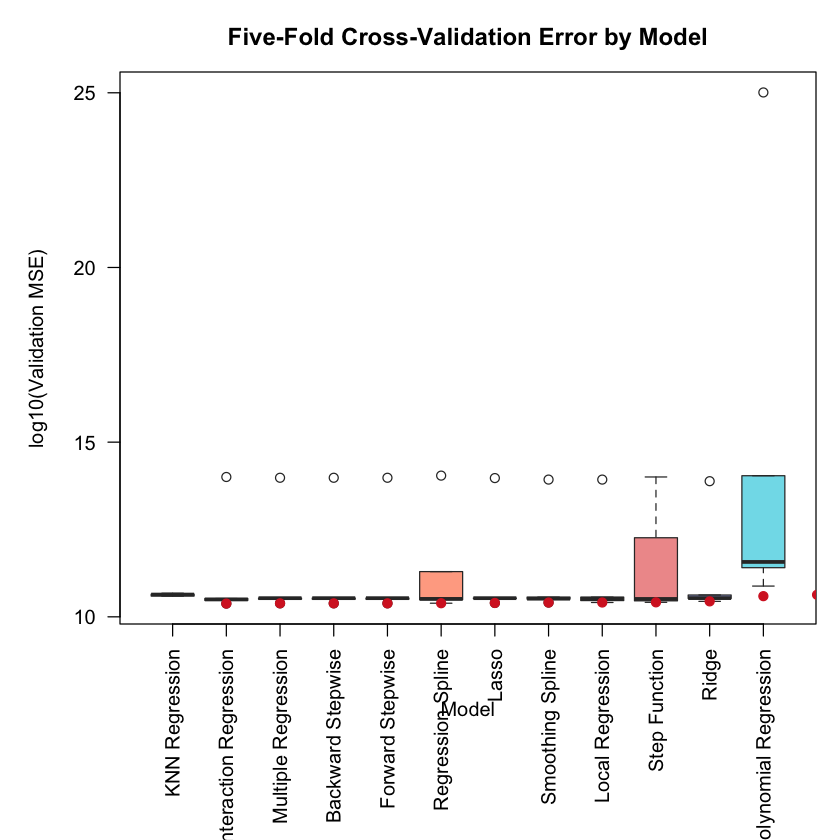

In [514]:
# 20: Plot the k-fold cross-validation comparison

cv_results_plot <- subset(cv_results, is.finite(Validation_MSE) & Validation_MSE > 0)
cv_summary_plot <- subset(cv_summary, is.finite(Mean_MSE) & Mean_MSE > 0)
model_order <- unique(as.character(cv_summary_plot$Model))
cv_results_plot$Model <- factor(as.character(cv_results_plot$Model), levels = model_order)
cv_summary_plot$Model <- factor(as.character(cv_summary_plot$Model), levels = model_order)

par(mar = c(9, 5, 3, 1))
boxplot(
  log10(Validation_MSE) ~ Model,
  data = cv_results_plot,
  las = 2,
  col = c("#90CAF9", "#FFCC80", "#A5D6A7", "#CE93D8", "#80CBC4", "#FFAB91", "#B39DDB", "#B0BEC5", "#FFF59D", "#EF9A9A", "#9FA8DA", "#80DEEA"),
  border = "#333333",
  main = "Five-Fold Cross-Validation Error by Model",
  ylab = "log10(Validation MSE)"
)
points(seq_len(nrow(cv_summary_plot)), log10(cv_summary_plot$Mean_MSE), pch = 19, col = "#D62728")


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the K-Fold CV Plot</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In this boxplot, each model has five validation errors, one from each fold. A <b>lower box</b> means lower validation error on average, and a <b>narrower box</b> means more stability across folds. The red points mark the mean validation MSE for each model. The vertical axis is shown on a <b>log10 scale</b>, which makes the comparison easier to read because a few extreme folds were stretching the original scale too much.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In this specific run, the most important thing is not the exact ordering but the <b>extreme spread</b> for several methods. Some flexible models show very large fold-to-fold swings, which means their performance depends heavily on the data partition. So this figure should be read as a <b>robustness warning</b>: some methods can perform very well on one split and very poorly on another. That is why the final decision in this notebook should rely more on the testing-set ranking than on this single CV summary.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 20B. Validation-Set Comparison</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    We now compare all fitted models on the same shared training-evaluation sample and on the same shared testing-evaluation sample. This gives us a consistent <b>validation set approach</b> ranking from best to worst.
  </p>
</div>


In [515]:
# 20B: Build common training and testing comparison tables for all models

regression_model_registry[["Multiple Regression"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = predict(multiple_regression_model, newdata = comparison_training_eval),
  test_actual = comparison_testing_eval$price,
  test_pred = predict(multiple_regression_model, newdata = comparison_testing_eval)
)

regression_model_registry[["Interaction Regression"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = predict(interaction_model, newdata = comparison_training_eval),
  test_actual = comparison_testing_eval$price,
  test_pred = predict(interaction_model, newdata = comparison_testing_eval)
)

regression_model_registry[["Polynomial Regression"]] <- list(
  train_actual = comparison_training_eval$price,
  train_pred = predict(best_power_model, newdata = comparison_training_eval),
  test_actual = comparison_testing_eval$price,
  test_pred = predict(best_power_model, newdata = comparison_testing_eval)
)

build_comparison_row <- function(model_name, dataset_name, actual, predicted) {
  metric_row <- compute_regression_metrics(actual, predicted)
  data.frame(
    Model = model_name,
    Dataset = dataset_name,
    MSE = metric_row$MSE,
    RMSE = metric_row$RMSE,
    MAE = metric_row$MAE,
    R_Squared = metric_row$R_Squared,
    stringsAsFactors = FALSE
  )
}

comparison_rows <- do.call(
  rbind,
  lapply(names(regression_model_registry), function(model_name) {
    model_entry <- regression_model_registry[[model_name]]
    rbind(
      build_comparison_row(model_name, "Training", model_entry$train_actual, model_entry$train_pred),
      build_comparison_row(model_name, "Testing", model_entry$test_actual, model_entry$test_pred)
    )
  })
)

training_comparison_table <- comparison_rows[comparison_rows$Dataset == "Training", ]
training_comparison_table <- training_comparison_table[order(training_comparison_table$RMSE), ]
training_comparison_table$Rank <- seq_len(nrow(training_comparison_table))
training_comparison_table <- training_comparison_table[, c("Rank", "Model", "MSE", "RMSE", "MAE", "R_Squared")]

testing_comparison_table <- comparison_rows[comparison_rows$Dataset == "Testing", ]
testing_comparison_table <- testing_comparison_table[order(testing_comparison_table$RMSE), ]
testing_comparison_table$Rank <- seq_len(nrow(testing_comparison_table))
testing_comparison_table <- testing_comparison_table[, c("Rank", "Model", "MSE", "RMSE", "MAE", "R_Squared")]

training_comparison_table
testing_comparison_table


,Rank,Model,MSE,RMSE,MAE,R_Squared
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
11,1,Regression Spline,25448511745,159525.9,116843.0,0.4999632
23,2,Polynomial Regression,25779961631,160561.4,117431.7,0.4934505
13,3,Smoothing Spline,27368869221,165435.4,120902.7,0.4622301
15,4,Local Regression,27565998828,166030.1,121309.7,0.4583567
3,5,Backward Stepwise,28410763627,168554.9,125453.4,0.4417580
1,6,Forward Stepwise,28410763627,168554.9,125453.4,0.4417580
21,7,Interaction Regression,28699387175,169408.9,126715.8,0.4360868
19,8,Multiple Regression,29381726346,171411.0,129126.7,0.4226796
17,9,KNN Regression,38836290482,197069.3,152598.5,0.2369072


,Rank,Model,MSE,RMSE,MAE,R_Squared
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
12,1,Regression Spline,29268821138,171081.3,124188.1,0.45628327
10,2,Step Function,29406428926,171483.0,125864.6,0.45372698
24,3,Polynomial Regression,29846797727,172762.3,125186.9,0.44554640
14,4,Smoothing Spline,32030719767,178971.3,128127.0,0.40497644
16,5,Local Regression,32469814448,180193.8,128309.5,0.39681953
22,6,Interaction Regression,32587150576,180519.1,132800.4,0.39463982
2,7,Forward Stepwise,32905058833,181397.5,131737.0,0.38873414
4,8,Backward Stepwise,32905058833,181397.5,131737.0,0.38873414
20,9,Multiple Regression,33187441321,182174.2,135210.0,0.38348842


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">Interpretation</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    The training and testing rankings point to the same broad conclusion: the strongest models are the ones that allow a <b>flexible nonlinear effect for house_size</b>. On the training side, <b>Regression Spline</b> ranks first, followed by <b>Polynomial Regression</b>, <b>Smoothing Spline</b>, and <b>Local Regression</b>. On the testing side, the top three models are <b>Regression Spline</b>, <b>Step Function</b>, and <b>Polynomial Regression</b>. That consistency is strong evidence that the size effect is nonlinear and that flexible regression methods are the right direction.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    The linear-family models remain useful benchmarks, but they sit in the middle of the pack. Forward and backward stepwise tie, and both remain below the interaction model and well below the best spline-based methods. <b>Ridge</b>, <b>Lasso</b>, and <b>KNN Regression</b> are the weakest test performers in this run, which means that shrinkage and local distance averaging did not solve the main predictive challenge as effectively as flexible functional form did.
  </p>
</div>


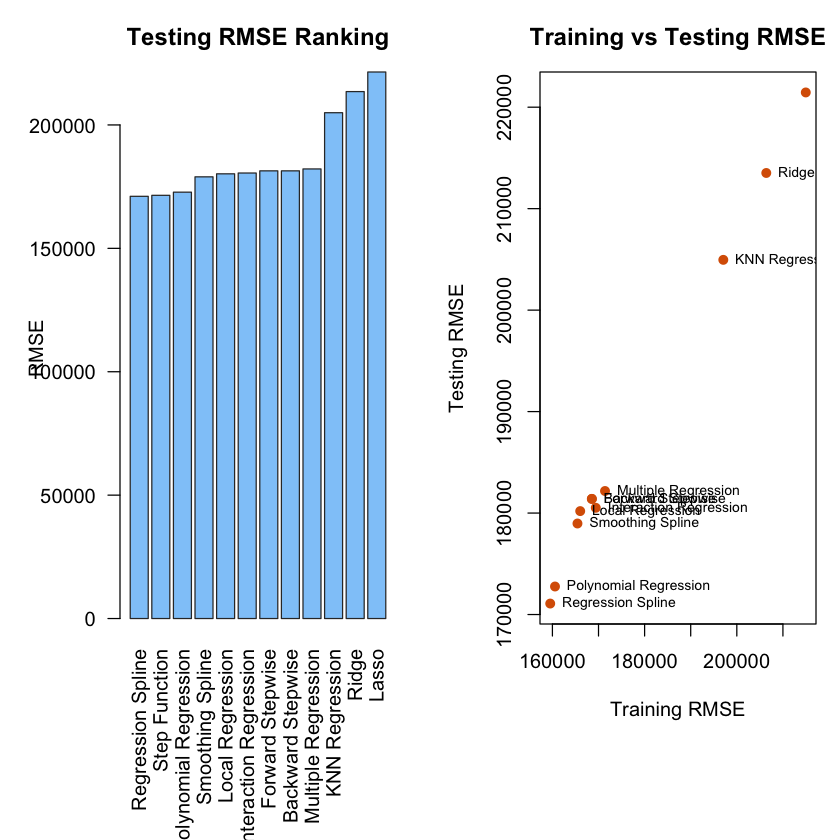

In [516]:
# 20B: Plot the final testing-set ranking

par(mfrow = c(1, 2), mar = c(9, 5, 3, 1))
barplot(
  testing_comparison_table$RMSE,
  names.arg = testing_comparison_table$Model,
  las = 2,
  col = "#90CAF9",
  border = "#333333",
  main = "Testing RMSE Ranking",
  ylab = "RMSE"
)

plot(
  training_comparison_table$RMSE,
  testing_comparison_table$RMSE[match(training_comparison_table$Model, testing_comparison_table$Model)],
  pch = 16,
  cex = 1.1,
  col = "#D95F02",
  xlab = "Training RMSE",
  ylab = "Testing RMSE",
  main = "Training vs Testing RMSE"
)
text(
  training_comparison_table$RMSE,
  testing_comparison_table$RMSE[match(training_comparison_table$Model, testing_comparison_table$Model)],
  labels = training_comparison_table$Model,
  pos = 4,
  cex = 0.7
)
par(mfrow = c(1, 1))


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h3 style="color: #8C1C13; margin-bottom: 8px;">How to Read the Final Comparison Plots</h3>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    In the <b>Testing RMSE Ranking</b> bar chart, shorter bars are better because they represent lower prediction error on unseen data. In this run, <b>Regression Spline</b> has the lowest testing RMSE, followed very closely by <b>Step Function</b> and <b>Polynomial Regression</b>. This tells us that the best-performing models are the ones that treat <b>house_size</b> as a nonlinear predictor.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    In the <b>Training vs Testing RMSE</b> scatterplot, each point is one model. Points close to the diagonal show similar training and testing error, which suggests more stable generalization. Points far away from that balance indicate that performance changes noticeably from training to testing. The most attractive final models are those that stay toward the <b>lower-left corner</b> while remaining reasonably close to the general trend, because that means they are both accurate and relatively stable.
  </p>
</div>


<div style="font-family: Arial, sans-serif; user-select: text; -webkit-user-select: text; cursor: text;">
  <h2 style="color: #12355B; margin-bottom: 8px;">Step 21. Conclusion</h2>
  <p style="font-size: 16px; color: #222222; line-height: 1.7; margin-top: 0;">
    This project shows a consistent message: <b>house_size has a strong nonlinear relationship with price</b>, and the best-performing models are the ones that allow that effect to bend smoothly. Starting from a baseline multiple regression, we saw moderate gains from interaction terms, much larger gains from power terms, and the strongest overall performance from spline-based methods.
  </p>
  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    Based on the testing ranking, the <b>best overall model is the Regression Spline</b>, with a testing RMSE of about <b>$171,081</b> and a testing R<sup>2</sup> of about <b>0.456</b>. The closest alternatives are the <b>Step Function</b> and the <b>Polynomial Regression</b>, which also perform strongly and confirm that the size effect is not linear. By contrast, <b>Ridge</b>, <b>Lasso</b>, and <b>KNN Regression</b> are not competitive in this dataset. Ridge and lasso add shrinkage, but they do not capture the main curvature pattern; KNN loses too much information because it uses only scaled numeric predictors and misses the strong location structure.
  </p>
  <ul style="font-size: 16px; color: #222222; line-height: 1.8; padding-left: 22px; margin-top: 0;">
    <li><b>Best final candidate:</b> Regression Spline.</li>
    <li><b>Strong supporting alternatives:</b> Step Function and Polynomial Regression.</li>
    <li><b>Best linear-family simplification:</b> Forward and Backward Stepwise, which converged to the same final model.</li>
    <li><b>Main substantive insight:</b> location and bathroom count matter a lot, but the biggest modeling gain comes from treating <b>house_size</b> as a nonlinear predictor.</li>
  </ul>
  <div style="background: #EFF6FF; border: 1px solid #93C5FD; border-left: 6px solid #2563EB; padding: 12px 14px; border-radius: 10px; margin-top: 12px;">
    <p style="margin: 0; font-size: 15px; color: #1E3A8A; line-height: 1.7;">
      The most defensible conclusion is that <b>Regression Splines provide the best balance of predictive performance and interpretable nonlinear structure</b>. The k-fold step in this run showed instability for several models, so the final recommendation should rely primarily on the <b>testing-set ranking</b>, with k-fold used as a cautionary robustness check rather than the sole decision rule.
    </p>
  </div>

  <p style="font-size: 16px; color: #222222; line-height: 1.7;">
    Polynomial regression also deserves a nuanced interpretation: it was one of the strongest models in average predictive performance, but its larger boxplot in the five-fold cross-validation step showed <b>lower stability across folds</b>. In other words, it can predict very well, but its validation error is more sensitive to the particular train-validation split than the most stable alternatives.
  </p>
</div>
